# Last Full Month From Sales CSV

This notebook loads `data/raw/sales_hrs_all.csv`, finds the last complete calendar month in the data, and prepares a filtered dataframe for downstream heatmaps.


## Demand comparison for one bakery and one product

This block loads the last full month from `sales_hrs_all.csv`, saves it as a separate CSV, and compares actual vs expected hourly sales for a chosen bakery-product pair.


In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.dates import DayLocator, DateFormatter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

ROOT = Path(r'C:/Users/dns/Desktop/Projects/demand-forecasting-model')
SOURCE_CSV = ROOT / 'data' / 'raw' / 'sales_hrs_all.csv'
MONTH_OUT = ROOT / 'data' / 'processed' / 'sales_hrs_last_full_month.csv'
REPORT_DIR = ROOT / 'reports' / 'monthly_demand_review'

DATE_COL = 'Дата продажи'
DATETIME_COL = 'Дата время чека'
EVENT_COL = 'Вид события по кассе'
BAKERY_COL = 'Касса.Торговая точка'
PRODUCT_COL = 'Номенклатура'
QTY_COL = 'Кол-во'
SALES_EVENT = 'Продажа'

# Fill these manually before running the comparison.
# TARGET_BAKERY = 'Проспект Победы 147 Казань'
TARGET_BAKERY = 'Вахитова 20 Наб Челны'
TARGET_PRODUCT = 'Вак-бэлиш'

CHUNK_SIZE = 500_000


In [2]:
df = pd.read_csv('C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/raw/sales_hrs_all.csv')

In [253]:
def build_comparison(month_df: pd.DataFrame, bakery: str, product: str):
    bakery_df = month_df[month_df[BAKERY_COL] == bakery].copy()
    if bakery_df.empty:
        raise ValueError(f'Bakery not found in selected month: {bakery}')
    bakery_df['date'] = bakery_df[DATE_COL].dt.normalize()
    product_df = bakery_df[bakery_df[PRODUCT_COL] == product].copy()
    if product_df.empty:
        raise ValueError(f'Product not found for bakery {bakery}: {product}')

    bakery_daily = bakery_df.groupby('date', as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: 'bakery_total_qty'})
    product_daily = product_df.groupby('date', as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: 'actual_product_qty'})
    comparison = bakery_daily.merge(product_daily, on='date', how='left')
    comparison['actual_product_qty'] = comparison['actual_product_qty'].fillna(0.0)
    comparison['daily_share'] = comparison['actual_product_qty'] / comparison['bakery_total_qty'].where(comparison['bakery_total_qty'] > 0)

    average_daily_share = comparison['daily_share'].dropna().mean()
    if pd.isna(average_daily_share):
        average_daily_share = 0.0

    comparison['expected_daily_qty'] = comparison['bakery_total_qty'] * average_daily_share
    comparison['gap_qty'] = comparison['expected_daily_qty'] - comparison['actual_product_qty']
    comparison['share_gap'] = comparison['daily_share'] - average_daily_share

    daily = comparison[['date', 'bakery_total_qty', 'actual_product_qty', 'daily_share', 'expected_daily_qty', 'gap_qty', 'share_gap']].copy()

    return comparison, daily, average_daily_share


def plot_comparison(daily: pd.DataFrame, average_daily_share: float, bakery: str, product: str, month_tag: str):
    REPORT_DIR.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(2, 1, figsize=(18, 12), gridspec_kw={'height_ratios': [2, 1]})

    daily_plot = daily.copy()
    daily_plot['date'] = pd.to_datetime(daily_plot['date'])

    axes[0].plot(daily_plot['date'], daily_plot['actual_product_qty'], label='Actual', linewidth=2, color='black')
    axes[0].plot(daily_plot['date'], daily_plot['expected_daily_qty'], label='Expected from average daily share', linewidth=2, color='#1f77b4')

    axes[0].set_title(f'{bakery} / {product} - actual vs expected')
    axes[0].legend()
    axes[0].grid(True, which='major', axis='x', linestyle='--', alpha=0.5)
    axes[0].grid(True, which='major', axis='y', alpha=0.3)

    axes[0].xaxis.set_major_locator(DayLocator(interval=1))
    axes[0].xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].plot(daily_plot['date'], daily_plot['daily_share'], marker='o', linewidth=1.5, color='#d95f02', label='Daily share')
    axes[1].axhline(average_daily_share, color='#1f77b4', linestyle='--', linewidth=2, label=f'Average share = {average_daily_share:.4f}')
    axes[1].set_title('Daily share of product in bakery sales')
    axes[1].set_ylabel('Share')
    axes[1].legend()
    axes[1].grid(True, axis='y', alpha=0.3)
    axes[1].xaxis.set_major_locator(DayLocator(interval=1))
    axes[1].xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    out_path = REPORT_DIR / f'{month_tag}_{bakery}_{product}_comparison.png'
    fig.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    return out_path


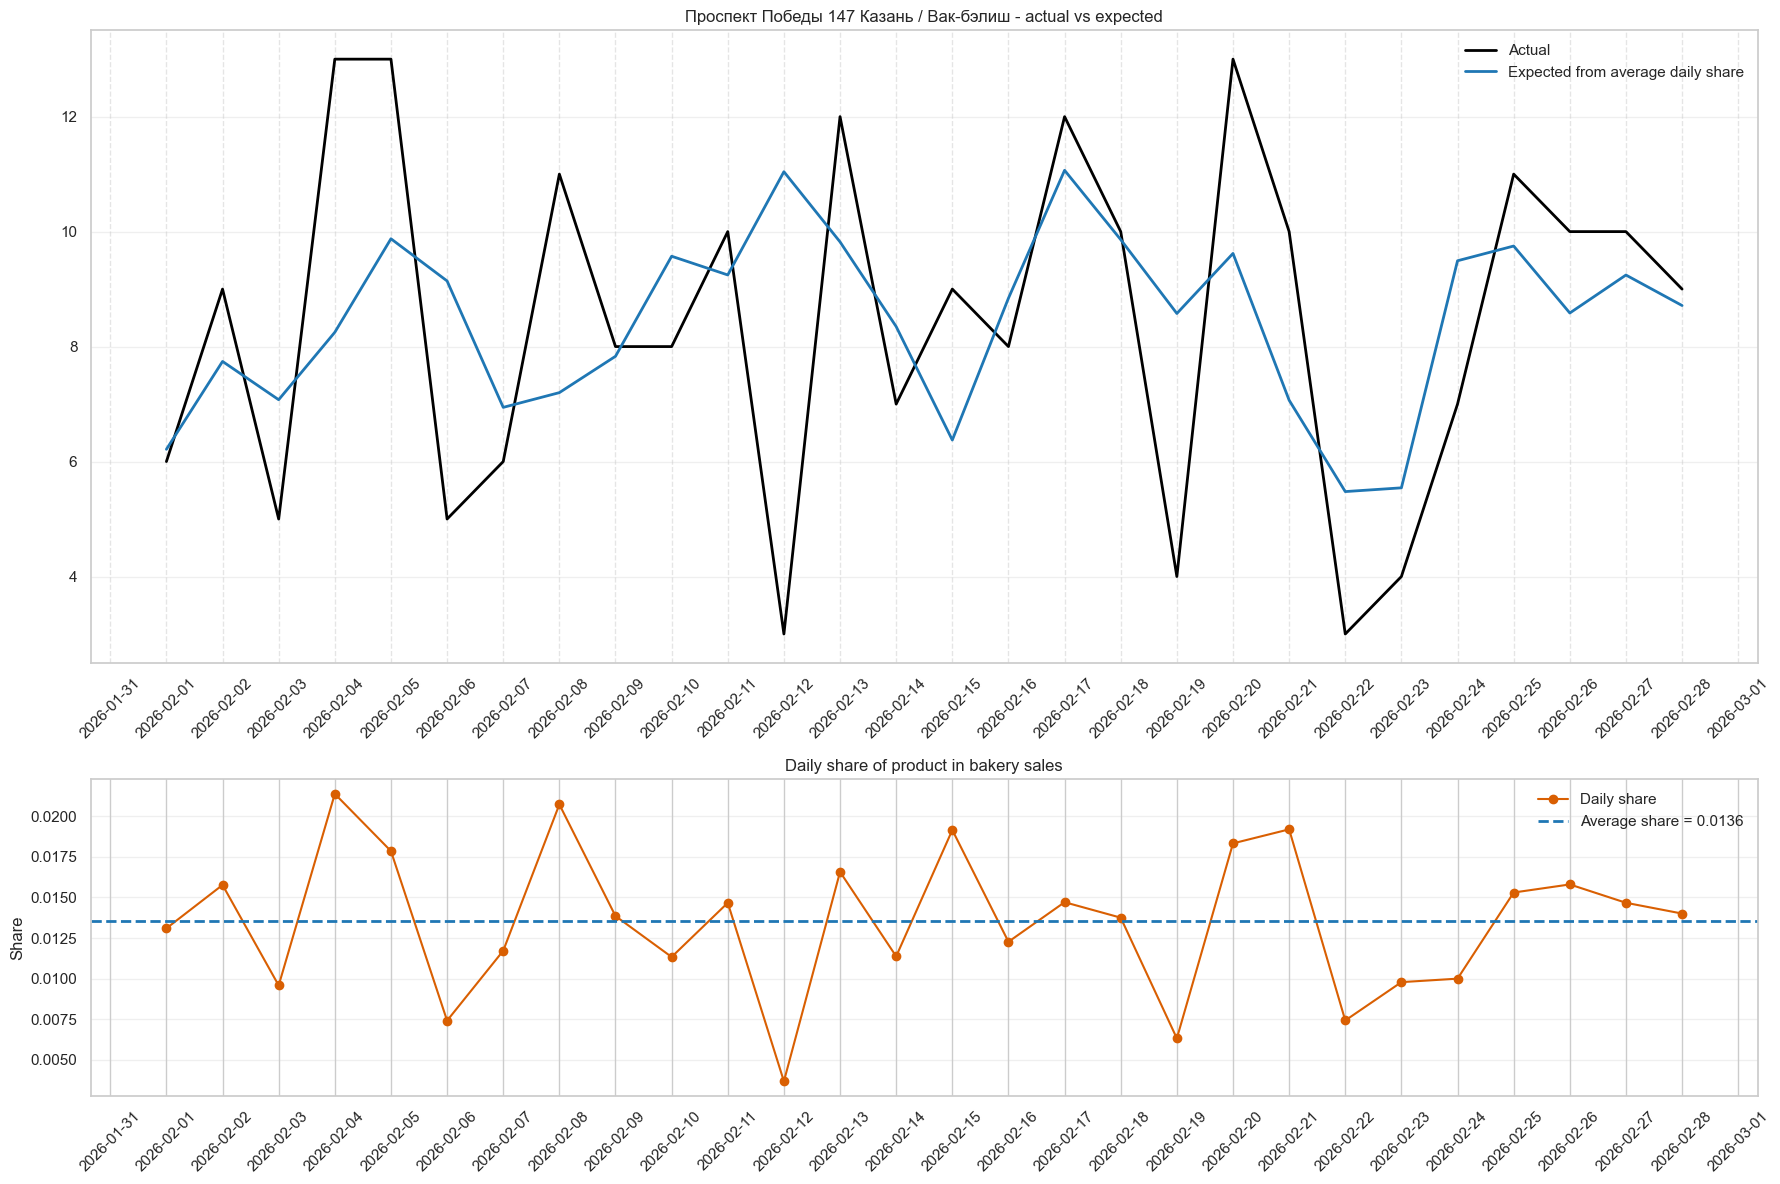

Bakery: Проспект Победы 147 Казань
Product: Вак-бэлиш
Total actual: 236.0
Total expected: 236.51
Average daily share: 0.0136
Uplift %: 0.22
Plot saved to: C:\Users\dns\Desktop\Projects\demand-forecasting-model\reports\monthly_demand_review\2026_02_Проспект Победы 147 Казань_Вак-бэлиш_comparison.png


In [15]:
if TARGET_BAKERY and TARGET_PRODUCT:
    comparison, daily, average_daily_share = build_comparison(month_df, TARGET_BAKERY, TARGET_PRODUCT)
    bakery_tag = TARGET_BAKERY.replace('/', '_').replace('\\', '_')
    product_tag = TARGET_PRODUCT.replace('/', '_').replace('\\', '_')
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    comparison.to_csv(REPORT_DIR / f'{month_tag}_{bakery_tag}_{product_tag}_daily_comparison.csv', index=False, encoding='utf-8-sig')
    daily.to_csv(REPORT_DIR / f'{month_tag}_{bakery_tag}_{product_tag}_daily_profile.csv', index=False, encoding='utf-8-sig')
    plot_path = plot_comparison(daily, average_daily_share, TARGET_BAKERY, TARGET_PRODUCT, month_tag)
    total_actual = float(comparison['actual_product_qty'].sum())
    total_expected = float(comparison['expected_daily_qty'].sum())
    uplift = (total_expected - total_actual) / total_actual * 100 if total_actual > 0 else 0.0
    print('Bakery:', TARGET_BAKERY)
    print('Product:', TARGET_PRODUCT)
    print('Total actual:', round(total_actual, 2))
    print('Total expected:', round(total_expected, 2))
    print('Average daily share:', round(average_daily_share, 4))
    print('Uplift %:', round(uplift, 2))
    print('Plot saved to:', plot_path)
else:
    print('Set TARGET_BAKERY and TARGET_PRODUCT, then rerun this cell.')


## Hourly and daily profiles together

This block compares the hourly share profile in the bakery flow with the daily share profile for the same bakery-product pair.


In [3]:
def build_hourly_and_daily_profiles(month_df: pd.DataFrame, bakery: str, product: str):
    bakery_df = month_df[month_df[BAKERY_COL] == bakery].copy()
    if bakery_df.empty:
        raise ValueError(f'Bakery not found in selected month: {bakery}')
    bakery_df["date"] = bakery_df[DATE_COL].dt.normalize()
    bakery_df["hour"] = bakery_df[DATETIME_COL].dt.hour
    product_df = bakery_df[bakery_df[PRODUCT_COL] == product].copy()
    if product_df.empty:
        raise ValueError(f'Product not found for bakery {bakery}: {product}')


#hourly--------------------------------------------------------------------
    bakery_hourly = bakery_df.groupby(["date", "hour"], as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_hour_qty"})
    product_hourly = product_df.groupby(["date", "hour"], as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "product_hour_qty"})
    hourly = bakery_hourly.merge(product_hourly, on=["date", "hour"], how="left")
    hourly["product_hour_qty"] = hourly["product_hour_qty"].fillna(0.0)
    hourly["hour_share"] = hourly["product_hour_qty"] / hourly["bakery_hour_qty"].where(hourly["bakery_hour_qty"] > 0)

    hourly_profile = (
        hourly.dropna(subset=["hour_share"])
        .groupby("hour", as_index=False)
        .agg(
            avg_hour_share=("hour_share", "mean"),
            n_obs=("hour_share", "count"),
            n_days=("date", "nunique"),
        )
    )
    hourly_profile = pd.DataFrame({"hour": list(range(24))}).merge(hourly_profile, on="hour", how="left")

    hourly = hourly.merge(hourly_profile, on="hour", how="left")
    hourly["expected_hour_qty"] = hourly["bakery_hour_qty"] * hourly["avg_hour_share"]
    daily_from_hourly = (
        hourly.groupby("date", as_index=False)[["bakery_hour_qty", "product_hour_qty", "expected_hour_qty"]]
        .sum()
        .rename(columns={
            "bakery_hour_qty": "bakery_daily_qty",
            "product_hour_qty": "actual_daily_qty_from_hourly",
            "expected_hour_qty": "expected_daily_qty_from_hourly",
        })
    )


# zero_less ---------------------------------------------------------------

    hourly_zero_less = hourly[hourly["product_hour_qty"] > 0].copy()

    hourly_profile_zero_less = (
        hourly_zero_less
        .dropna(subset=["hour_share"])
        .groupby("hour", as_index=False)
        .agg(
            avg_hour_share_zero_less=("hour_share", "mean"),
            n_obs_zero_less=("hour_share", "count"),
            n_days_zero_less=("date", "nunique"),
        )
    )

    hourly_profile_zero_less = (
        pd.DataFrame({"hour": list(range(24))})
        .merge(hourly_profile_zero_less, on="hour", how="left")
    )

    hourly_zero_less = hourly.merge(
        hourly_profile_zero_less,
        on="hour",
        how="left"
    )

    hourly_zero_less["avg_hour_share_zero_less"] = (
        hourly_zero_less["avg_hour_share_zero_less"]
        .fillna(0.0)
    )

    hourly_zero_less["expected_hour_qty_zero_less"] = (
        hourly_zero_less["bakery_hour_qty"] *
        hourly_zero_less["avg_hour_share_zero_less"]
    )

    daily_from_hourly_zero_less = (
        hourly_zero_less
        .groupby("date", as_index=False)[
            [
                "bakery_hour_qty",
                "product_hour_qty",
                "expected_hour_qty_zero_less",
            ]
        ]
        .sum()
        .rename(columns={
            "bakery_hour_qty": "bakery_daily_qty",
            "product_hour_qty": "actual_daily_qty_from_hourly",
            "expected_hour_qty_zero_less": "expected_daily_qty_from_hourly_zero_less",
        })
    )

#weekly--------------------------------------------------------------------
    bakery_daily = bakery_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_daily_qty"})
    product_daily = product_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "actual_daily_qty"})

    week_daily = bakery_daily.merge(product_daily, on="date", how="left")
    week_daily['weekday'] = week_daily['date'].dt.day_name()
    week_daily["actual_daily_qty"] = week_daily["actual_daily_qty"].fillna(0.0)
    week_daily["daily_share"] = week_daily["actual_daily_qty"] / week_daily["bakery_daily_qty"].where(week_daily["bakery_daily_qty"] > 0)

    weekday_avg_share = (
    week_daily
    .groupby("weekday", as_index=False)["daily_share"]
    .mean()
    .rename(columns={"daily_share": "average_week_daily_share"})
    )
    week_daily = week_daily.merge(weekday_avg_share, on="weekday", how="left")
    week_daily["average_week_daily_share"] = week_daily["average_week_daily_share"].fillna(0.0)


    week_daily["expected_week_daily_qty_from_daily"] = week_daily["bakery_daily_qty"] * week_daily["average_week_daily_share"]
    week_daily["gap_week_daily"] = week_daily["expected_week_daily_qty_from_daily"] - week_daily["actual_daily_qty"]
    week_daily["share_gap"] = week_daily["daily_share"] - week_daily["average_week_daily_share"]

    week_daily = week_daily.merge(daily_from_hourly[["date", "expected_daily_qty_from_hourly"]], on="date", how="left")
    week_daily["gap_hourly"] = week_daily["expected_daily_qty_from_hourly"] - week_daily["actual_daily_qty"]
#daily--------------------------------------------------------------------

    bakery_daily = bakery_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_daily_qty"})
    product_daily = product_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "actual_daily_qty"})
    daily = bakery_daily.merge(product_daily, on="date", how="left")
    daily["actual_daily_qty"] = daily["actual_daily_qty"].fillna(0.0)
    daily["daily_share"] = daily["actual_daily_qty"] / daily["bakery_daily_qty"].where(daily["bakery_daily_qty"] > 0)

    average_daily_share = daily["daily_share"].dropna().mean()
    if pd.isna(average_daily_share):
        average_daily_share = 0.0
    
    daily["average_daily_share"] = average_daily_share

    daily["expected_daily_qty_from_daily"] = daily["bakery_daily_qty"] * average_daily_share
    daily["gap_daily"] = daily["expected_daily_qty_from_daily"] - daily["actual_daily_qty"]
    daily["share_gap"] = daily["daily_share"] - average_daily_share

    daily = daily.merge(daily_from_hourly[["date", "expected_daily_qty_from_hourly"]], on="date", how="left")
    daily = daily.merge(daily_from_hourly_zero_less[["date", "expected_daily_qty_from_hourly_zero_less"]], on="date", how="left")
    daily["gap_hourly"] = daily["expected_daily_qty_from_hourly"] - daily["actual_daily_qty"]


#q1--------------------------------------------------------------------

    bakery_daily = bakery_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_daily_qty"})
    product_daily = product_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "actual_daily_qty"})
    qdaily = bakery_daily.merge(product_daily, on="date", how="left")
    qdaily["actual_daily_qty"] = qdaily["actual_daily_qty"].fillna(0.0)

    qdaily["daily_share"] = qdaily["actual_daily_qty"] / qdaily["bakery_daily_qty"].where(qdaily["bakery_daily_qty"] > 0)

    q10 = daily["daily_share"].quantile(0.2)
    
    filtered = qdaily[qdaily["daily_share"] > q10].copy()

    average_daily_share = filtered["daily_share"].dropna().mean()
    if pd.isna(average_daily_share):
        average_daily_share = 0.0
    
    filtered["average_daily_share"] = average_daily_share

    filtered["expected_daily_qty_from_daily"] = filtered["bakery_daily_qty"] * average_daily_share
    filtered["gap_daily"] = filtered["expected_daily_qty_from_daily"] - filtered["actual_daily_qty"]
    filtered["share_gap"] = filtered["daily_share"] - average_daily_share

    filtered = filtered.merge(daily_from_hourly[["date", "expected_daily_qty_from_hourly"]], on="date", how="left")
    filtered["gap_hourly"] = filtered["expected_daily_qty_from_hourly"] - filtered["actual_daily_qty"]

    return hourly, hourly_profile, daily, week_daily, filtered, hourly_zero_less, average_daily_share

def plot_hourly_and_daily_profiles(daily: pd.DataFrame, hourly_profile: pd.DataFrame, average_daily_share: float, bakery: str, product: str, month_tag: str):
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(3, 1, figsize=(18, 15), gridspec_kw={"height_ratios": [2, 1, 1]})

    daily_plot = daily.copy()
    daily_plot["date"] = pd.to_datetime(daily_plot["date"])

    axes[0].plot(daily_plot["date"], daily_plot["actual_daily_qty"], label="Actual", linewidth=2, color="black")
    axes[0].plot(daily_plot["date"], daily_plot["expected_daily_qty_from_daily"], label="Expected from daily share", linewidth=2, color="#1f77b4")
    axes[0].plot(daily_plot["date"], daily_plot["expected_daily_qty_from_hourly"], label="Expected from hourly profile", linewidth=2, color="#d62728")
    axes[0].set_title(f"{bakery} / {product} - actual vs both expected series")
    axes[0].legend()
    axes[0].grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
    axes[0].grid(True, which="major", axis="y", alpha=0.3)
    axes[0].xaxis.set_major_locator(DayLocator(interval=1))
    axes[0].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    axes[0].tick_params(axis="x", rotation=45)

    hourly_plot = hourly_profile.sort_values("hour")
    axes[1].plot(hourly_plot["hour"], hourly_plot["avg_hour_share"], marker="o", linewidth=2, color="#d95f02")
    axes[1].set_title("Average hourly share in bakery flow")
    axes[1].set_xticks(list(range(24)))
    axes[1].set_xticklabels([f"{h:02d}:00" for h in range(24)])
    axes[1].grid(True, axis="y", alpha=0.3)

    axes[2].plot(daily_plot["date"], daily_plot["daily_share"], marker="o", linewidth=1.5, color="#2ca02c", label="Daily share")
    axes[2].axhline(average_daily_share, color="#1f77b4", linestyle="--", linewidth=2, label=f"Average daily share = {average_daily_share:.4f}")
    axes[2].set_title("Daily share of product in bakery sales")
    axes[2].set_ylabel("Share")
    axes[2].legend()
    axes[2].grid(True, axis="y", alpha=0.3)
    axes[2].xaxis.set_major_locator(DayLocator(interval=1))
    axes[2].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    out_path = REPORT_DIR / f"{month_tag}_{bakery}_{product}_hourly_daily_comparison.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    return out_path




In [20]:
df.columns

Index(['Дата продажи', 'Дата время чека', 'Вид события по кассе',
       'Касса.Торговая точка', 'Категория', 'Номенклатура', 'Свежесть', 'Цена',
       'Кол-во'],
      dtype='object')

In [4]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", dayfirst=True)
df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors="coerce", dayfirst=True)

In [5]:
len(df['Дата продажи'].unique())

237

In [214]:
df[[DATE_COL, DATETIME_COL]].dtypes

Дата продажи       datetime64[ns]
Дата время чека    datetime64[ns]
dtype: object

In [5]:
month_tag = '2026_03'

In [6]:
days_share = (
    df.groupby(PRODUCT_COL)[DATE_COL]
    .nunique()
    / df[DATE_COL].nunique()
)

valid_products = days_share[days_share >= 0.98].index

df_filtered = df[df[PRODUCT_COL].isin(valid_products)]

In [139]:
df_filtered

,Дата продажи,Дата время чека,Вид события по кассе,Касса.Торговая точка,Категория,Номенклатура,Свежесть,Цена,Кол-во
0,2026-01-01,2026-01-01 14:21:01,Продажа,Раскольникова 48/1 Наб Челны,Напитки горячие,Капучино 300,NaN,130.0,1.0
2,2026-01-01,2026-01-01 14:34:10,Продажа,Раскольникова 48/1 Наб Челны,Прочие товары,Тесто дрожжевое,NaN,150.0,0.5
4,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Кулинария сеть,Манты с говядиной и картофелем вес сеть,NaN,890.0,1.2
5,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Прочие товары,Пакет спасибо,Свежий,4.0,1.0
6,2026-01-02,2026-01-02 06:52:17,Отмена чека,Джалиля 60А Бугульма,Выпечка сытная,Вак-бэлиш,Свежий,52.0,1.0
...,...,...,...,...,...,...,...,...,...
29909053,2025-09-30,2025-09-30 23:31:40,Продажа,Энгельса 30 Зеленодольск,Пироги сладкие,Губадия,Свежий,415.0,1.0
29909054,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Кулинария сеть,Салат Цезарь вес сеть,NaN,849.0,0.2
29909055,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Прочие товары,Коррекс мал,Свежий,6.0,1.0
29909057,2025-09-30,2025-09-30 23:36:19,Продажа,Шамиля Усманова 47 Наб Челны,Напитки горячие,Капучино 300,Свежий,130.0,1.0


In [7]:
hourly_df, hourly_profile_df, daily_df,week_daily_df, daily_q1_df, hourly_zero_less_df,avg_daily_share = build_hourly_and_daily_profiles(
    df_filtered, TARGET_BAKERY, TARGET_PRODUCT
)

,date,hour,bakery_hour_qty,product_hour_qty,hour_share,avg_hour_share,n_obs,n_days,expected_hour_qty
0,2025-08-01,7,65.9,0.0,0.0,0.036284,233.0,233.0,2.391092
1,2025-08-01,8,54.6,0.0,0.0,0.024468,236.0,236.0,1.335943
2,2025-08-01,9,34.1,0.0,0.0,0.034170,236.0,236.0,1.165209
3,2025-08-01,10,39.5,0.0,0.0,0.016411,236.0,236.0,0.648236
4,2025-08-01,11,45.3,0.0,0.0,0.016964,236.0,236.0,0.768488
...,...,...,...,...,...,...,...,...,...
3436,2026-04-02,17,78.2,0.0,0.0,0.009525,236.0,236.0,0.744871
3437,2026-04-02,18,68.7,0.0,0.0,0.011716,236.0,236.0,0.804920
3438,2026-04-02,19,18.6,0.0,0.0,0.014862,235.0,235.0,0.276437
3439,2026-04-02,20,27.0,0.0,0.0,0.012811,232.0,232.0,0.345885


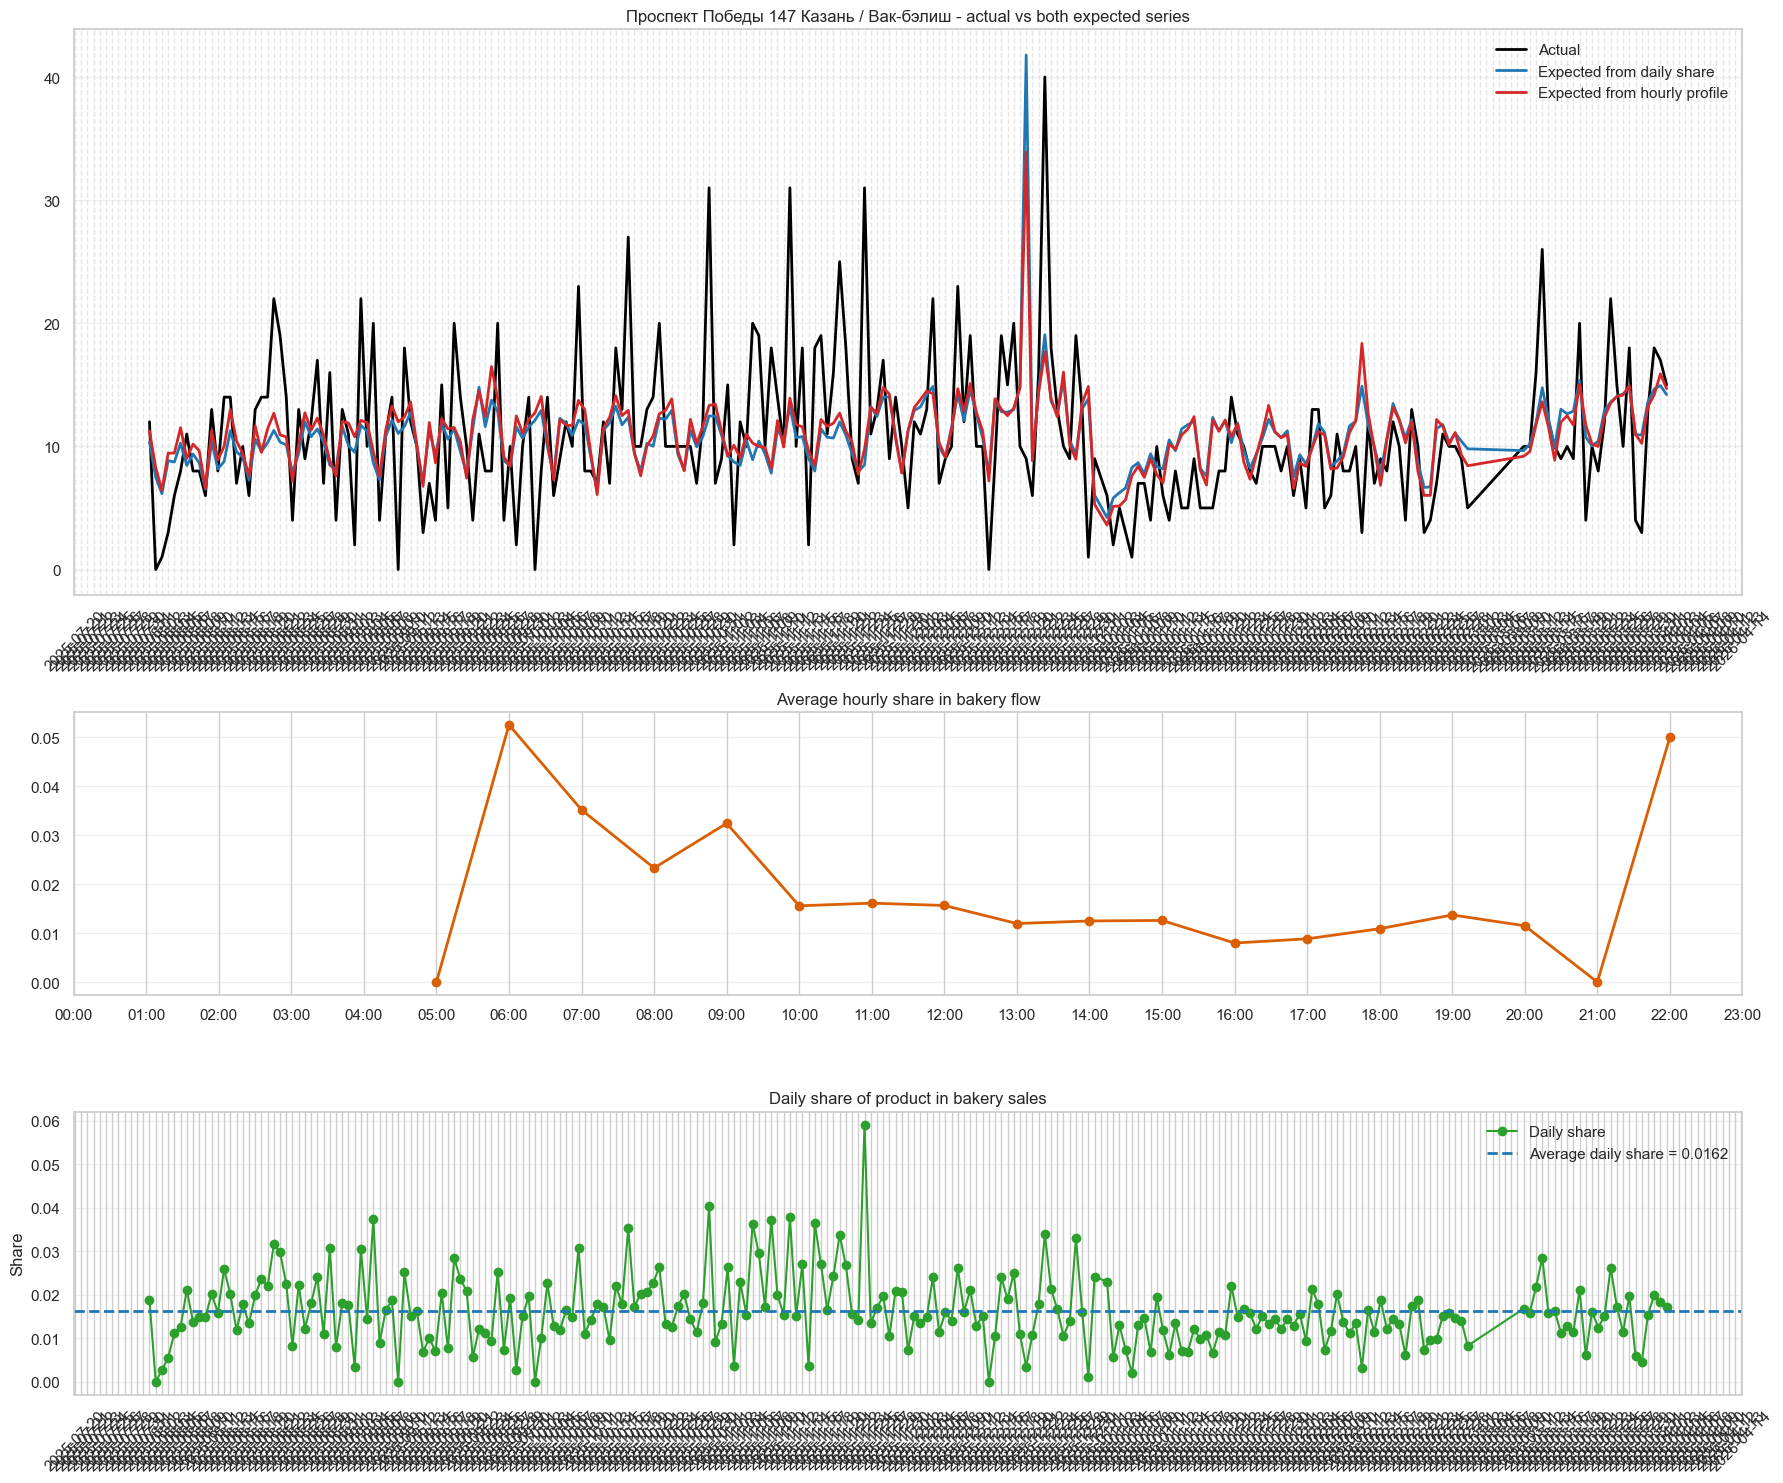

Plot saved to: C:\Users\dns\Desktop\Projects\demand-forecasting-model\reports\monthly_demand_review\2026_03_Проспект Победы 147 Казань_Вак-бэлиш_hourly_daily_comparison.png


In [8]:

bakery_tag = TARGET_BAKERY.replace("/", "_").replace("\\", "_")
product_tag = TARGET_PRODUCT.replace("/", "_").replace("\\", "_")
plot_path = plot_hourly_and_daily_profiles(daily_df, hourly_profile_df, avg_daily_share, TARGET_BAKERY, TARGET_PRODUCT, month_tag)
print("Plot saved to:", plot_path)

In [105]:
daily_df

,date,bakery_daily_qty,actual_daily_qty,daily_share,average_daily_share,expected_daily_qty_from_daily,gap_daily,share_gap,expected_daily_qty_from_hourly,expected_daily_qty_from_hourly_zero_less,gap_hourly
0,2025-08-01,568.0,12.0,0.021127,0.017333,9.845275,-2.154725,0.003794,10.519805,28.662138,-1.480195
1,2025-08-02,423.1,0.0,0.000000,0.017333,7.333690,7.333690,-0.017333,8.062806,22.018164,8.062806
2,2025-08-03,347.4,1.0,0.002879,0.017333,6.021565,5.021565,-0.014455,6.191566,20.742091,5.191566
3,2025-08-04,502.1,3.0,0.005975,0.017333,8.703015,5.703015,-0.011358,9.280492,28.190629,6.280492
4,2025-08-05,499.1,6.0,0.012022,0.017333,8.651016,2.651016,-0.005312,9.367937,26.516760,3.367937
...,...,...,...,...,...,...,...,...,...,...,...
231,2026-03-29,624.2,3.0,0.004806,0.017333,10.819403,7.819403,-0.012527,10.148256,30.568239,7.148256
232,2026-03-30,769.0,13.0,0.016905,0.017333,13.329255,0.329255,-0.000428,12.929704,39.524395,-0.070296
233,2026-03-31,847.1,18.0,0.021249,0.017333,14.682980,-3.317020,0.003916,14.120374,44.309146,-3.879626
234,2026-04-01,858.2,17.0,0.019809,0.017333,14.875379,-2.124621,0.002476,15.734372,51.545421,-1.265628


In [68]:
hourly_profile_df

,hour,avg_hour_share,n_obs,n_days
0,0,NaN,NaN,NaN
1,1,NaN,NaN,NaN
2,2,NaN,NaN,NaN
3,3,NaN,NaN,NaN
4,4,NaN,NaN,NaN
5,5,0.000000,2.0,2.0
6,6,0.053717,108.0,108.0
7,7,0.036284,233.0,233.0
8,8,0.024468,236.0,236.0
9,9,0.034170,236.0,236.0


In [70]:
hour7_20 = hourly_profile_df[(hourly_profile_df['hour'] >= 7) & (hourly_profile_df['hour'] <= 20)]

In [78]:
meanavg = hour7_20['avg_hour_share'].median()

In [103]:
hour7_20processed = hour7_20.copy()
hour7_20processed.loc[hour7_20processed['avg_hour_share'] < meanavg, 'avg_hour_share'] = meanavg


0      568.0
1      423.1
2      347.4
3      502.1
4      499.1
       ...  
231    624.2
232    769.0
233    847.1
234    858.2
235    806.9
Name: bakery_daily_qty, Length: 236, dtype: float64

In [77]:
hour7_20

,hour,avg_hour_share,n_obs,n_days
7,7,0.036284,233.0,233.0
8,8,0.024468,236.0,236.0
9,9,0.034170,236.0,236.0
10,10,0.016411,236.0,236.0
11,11,0.016964,236.0,236.0
12,12,0.016531,236.0,236.0
13,13,0.012619,236.0,236.0
14,14,0.013358,236.0,236.0
15,15,0.013593,236.0,236.0
16,16,0.008531,235.0,235.0


In [110]:
hour7_20processed

,hour,avg_hour_share,n_obs,n_days,bakery_daily_qty7_20
7,7,0.036284,233.0,233.0,19.299273
8,8,0.024468,236.0,236.0,11.705407
9,9,0.034170,236.0,236.0,12.366256
10,10,0.016411,236.0,236.0,9.536454
11,11,0.016964,236.0,236.0,7.627204
12,12,0.016531,236.0,236.0,8.151359
13,13,0.014227,236.0,236.0,9.370201
14,14,0.014227,236.0,236.0,7.799490
15,15,0.014227,236.0,236.0,7.483640
16,16,0.014227,235.0,235.0,5.858865


In [8]:
hourly_df

,date,hour,bakery_hour_qty,product_hour_qty,hour_share,avg_hour_share,n_obs,n_days,expected_hour_qty
0,2025-08-01,6,7.0,0.0,0.000000,0.009288,77.0,77.0,0.065015
1,2025-08-01,7,75.3,0.0,0.000000,0.021945,229.0,229.0,1.652449
2,2025-08-01,8,40.2,0.0,0.000000,0.028197,235.0,235.0,1.133523
3,2025-08-01,9,40.1,3.0,0.074813,0.026364,236.0,236.0,1.057215
4,2025-08-01,10,49.2,2.0,0.040650,0.021618,236.0,236.0,1.063590
...,...,...,...,...,...,...,...,...,...
3360,2026-04-02,16,52.0,0.0,0.000000,0.018161,236.0,236.0,0.944382
3361,2026-04-02,17,82.5,0.0,0.000000,0.019947,236.0,236.0,1.645645
3362,2026-04-02,18,39.2,0.0,0.000000,0.023284,236.0,236.0,0.912732
3363,2026-04-02,19,35.6,3.0,0.084270,0.021151,235.0,235.0,0.752983


In [119]:
hour7_20processed = hour7_20processed.rename(columns={'avg_hour_share': 'avg_hour_share_7_20'})



In [120]:
hourly_df = hourly_df.merge(hour7_20processed[['hour', 'avg_hour_share_7_20']], on='hour', how='left')



In [114]:
hourly_df = hourly_df.merge(daily_df[['date', 'bakery_daily_qty']], on='date', how='left')

In [122]:
hourly_df['expected_7_20'] = hourly_df['bakery_hour_qty'] * hourly_df['avg_hour_share_7_20']

In [143]:
hourly_df

,date,hour,bakery_hour_qty,product_hour_qty,hour_share,avg_hour_share,n_obs,n_days,expected_hour_qty
0,2025-08-01,7,43.0,0.0,0.0,0.062038,228.0,228.0,2.667628
1,2025-08-01,8,15.0,0.0,0.0,0.042410,236.0,236.0,0.636155
2,2025-08-01,9,10.0,0.0,0.0,0.061644,236.0,236.0,0.616443
3,2025-08-01,10,23.0,0.0,0.0,0.034633,235.0,235.0,0.796563
4,2025-08-01,11,17.0,0.0,0.0,0.039852,235.0,235.0,0.677488
...,...,...,...,...,...,...,...,...,...
3382,2026-04-02,16,24.0,0.0,0.0,0.018391,235.0,235.0,0.441381
3383,2026-04-02,17,26.0,0.0,0.0,0.022236,236.0,236.0,0.578132
3384,2026-04-02,18,28.0,0.0,0.0,0.033473,235.0,235.0,0.937246
3385,2026-04-02,19,10.0,0.0,0.0,0.035669,233.0,233.0,0.356693


In [23]:
daily_df

,date,bakery_daily_qty,actual_daily_qty,daily_share,average_daily_share,expected_daily_qty_from_daily,gap_daily,share_gap,expected_daily_qty_from_hourly,gap_hourly
0,2025-08-01,568.0,12.0,0.021127,0.017333,9.845275,-2.154725,0.003794,10.519805,-1.480195
1,2025-08-02,423.1,0.0,0.000000,0.017333,7.333690,7.333690,-0.017333,8.062806,8.062806
2,2025-08-03,347.4,1.0,0.002879,0.017333,6.021565,5.021565,-0.014455,6.191566,5.191566
3,2025-08-04,502.1,3.0,0.005975,0.017333,8.703015,5.703015,-0.011358,9.280492,6.280492
4,2025-08-05,499.1,6.0,0.012022,0.017333,8.651016,2.651016,-0.005312,9.367937,3.367937
...,...,...,...,...,...,...,...,...,...,...
231,2026-03-29,624.2,3.0,0.004806,0.017333,10.819403,7.819403,-0.012527,10.148256,7.148256
232,2026-03-30,769.0,13.0,0.016905,0.017333,13.329255,0.329255,-0.000428,12.929704,-0.070296
233,2026-03-31,847.1,18.0,0.021249,0.017333,14.682980,-3.317020,0.003916,14.120374,-3.879626
234,2026-04-01,858.2,17.0,0.019809,0.017333,14.875379,-2.124621,0.002476,15.734372,-1.265628


In [292]:
hourly_df

,date,hour,bakery_hour_qty,product_hour_qty,hour_share,avg_hour_share,n_obs,n_days,expected_hour_qty
0,2025-08-01,6,0.0,0.0,NaN,0.052538,110.0,110.0,0.000000
1,2025-08-01,7,72.9,0.0,0.0,0.035179,233.0,233.0,2.564514
2,2025-08-01,8,59.6,0.0,0.0,0.023293,236.0,236.0,1.388274
3,2025-08-01,9,38.1,0.0,0.0,0.032421,236.0,236.0,1.235222
4,2025-08-01,10,41.5,0.0,0.0,0.015575,236.0,236.0,0.646380
...,...,...,...,...,...,...,...,...,...
3443,2026-04-02,17,82.7,0.0,0.0,0.008832,236.0,236.0,0.730389
3444,2026-04-02,18,75.9,0.0,0.0,0.010892,236.0,236.0,0.826686
3445,2026-04-02,19,22.6,0.0,0.0,0.013707,235.0,235.0,0.309787
3446,2026-04-02,20,30.0,0.0,0.0,0.011495,232.0,232.0,0.344863


In [124]:
hour_7_20_daily = hourly_df.groupby("date", as_index=False)['expected_7_20'].sum()

In [128]:
hour_7_20_daily['expected_7_20_daily'] = hour_7_20_daily['expected_7_20'] / daily_df['bakery_daily_qty']

In [308]:
dt = '2026-2-08'
print(sum(daily_df[daily_df['date'] == dt]['expected_daily_qty_from_daily']))
print(sum(hourly_df[hourly_df['date'] == dt]['expected_hour_qty']))
print(sum(hourly_df[hourly_df['date'] == dt]['product_hour_qty']))

8.818207051589125
8.240273054422568
11.0


In [309]:
daily_df.groupby(["date"], as_index=False)['expected_daily_qty_from_daily'].sum().rename(columns={'expected_daily_qty_from_daily': "daily_qty"})

,date,daily_qty
0,2025-08-01,10.373598
1,2025-08-02,7.504477
2,2025-08-03,6.155066
3,2025-08-04,8.847401
4,2025-08-05,8.727381
...,...,...
231,2026-03-29,10.938015
232,2026-03-30,13.640081
233,2026-03-31,14.660249
234,2026-04-01,14.942458


In [10]:
max_date = daily_df["date"].max()

daily_last_30d = daily_df[
    daily_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

max_date = hourly_zero_less_df["date"].max()

zdaily_last_30d = hourly_zero_less_df[
    hourly_zero_less_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

hourly_zero_less_df

max_date = daily_q1_df["date"].max()

qdaily_last_30d = daily_q1_df[
    daily_q1_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

max_date = week_daily_df["date"].max()

wdaily_last_30d = week_daily_df[
    week_daily_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

# max_date = hour_7_20_daily["date"].max()

# hdaily_last_30d = hour_7_20_daily[
#     hour_7_20_daily["date"] >= (max_date - pd.Timedelta(days=29))
# ].copy()


In [57]:

zdaily_last_30d


,date,hour,bakery_hour_qty,product_hour_qty,hour_share,avg_hour_share,n_obs,n_days,expected_hour_qty,avg_hour_share_zero_less,n_obs_zero_less,n_days_zero_less,expected_hour_qty_zero_less
3088,2026-03-10,7,16.5,0.0,0.000000,0.036284,233.0,233.0,0.598680,0.071043,119.0,119.0,1.172206
3089,2026-03-10,8,61.0,3.0,0.049180,0.024468,236.0,236.0,1.492537,0.051101,113.0,113.0,3.117157
3090,2026-03-10,9,48.0,2.0,0.041667,0.034170,236.0,236.0,1.640178,0.069519,116.0,116.0,3.336913
3091,2026-03-10,10,20.2,0.0,0.000000,0.016411,236.0,236.0,0.331503,0.054549,71.0,71.0,1.101897
3092,2026-03-10,11,34.0,1.0,0.029412,0.016964,236.0,236.0,0.576790,0.043517,92.0,92.0,1.479593
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3436,2026-04-02,17,78.2,0.0,0.000000,0.009525,236.0,236.0,0.744871,0.038101,59.0,59.0,2.979485
3437,2026-04-02,18,68.7,0.0,0.000000,0.011716,236.0,236.0,0.804920,0.046866,59.0,59.0,3.219679
3438,2026-04-02,19,18.6,0.0,0.000000,0.014862,235.0,235.0,0.276437,0.062368,56.0,56.0,1.160047
3439,2026-04-02,20,27.0,0.0,0.000000,0.012811,232.0,232.0,0.345885,0.076206,39.0,39.0,2.057571


In [47]:
qdaily_last_30d

,date,bakery_daily_qty,actual_daily_qty,daily_share,average_daily_share,expected_daily_qty_from_daily,gap_daily,share_gap,expected_daily_qty_from_hourly,gap_hourly
167,2026-03-10,544.6,10.0,0.018362,0.02005,10.919333,0.919333,-0.001688,9.075011,-0.924989
168,2026-03-11,586.0,10.0,0.017065,0.02005,11.749411,1.749411,-0.002985,9.631157,-0.368843
169,2026-03-12,678.6,16.0,0.023578,0.02005,13.606058,-2.393942,0.003528,11.684253,-4.315747
170,2026-03-13,837.0,26.0,0.031063,0.02005,16.782008,-9.217992,0.011013,13.309477,-12.690523
171,2026-03-14,710.4,12.0,0.016892,0.02005,14.243654,2.243654,-0.003158,11.566640,-0.433360
172,2026-03-15,569.2,10.0,0.017569,0.02005,11.412568,1.412568,-0.002482,8.745174,-1.254826
173,2026-03-16,734.7,9.0,0.012250,0.02005,14.730874,5.730874,-0.007800,11.685150,2.685150
174,2026-03-17,702.1,10.0,0.014243,0.02005,14.077238,4.077238,-0.005807,12.127700,2.127700
175,2026-03-18,732.1,9.0,0.012293,0.02005,14.678743,5.678743,-0.007757,11.468239,2.468239
176,2026-03-19,879.2,20.0,0.022748,0.02005,17.628126,-2.371874,0.002698,14.953798,-5.046202


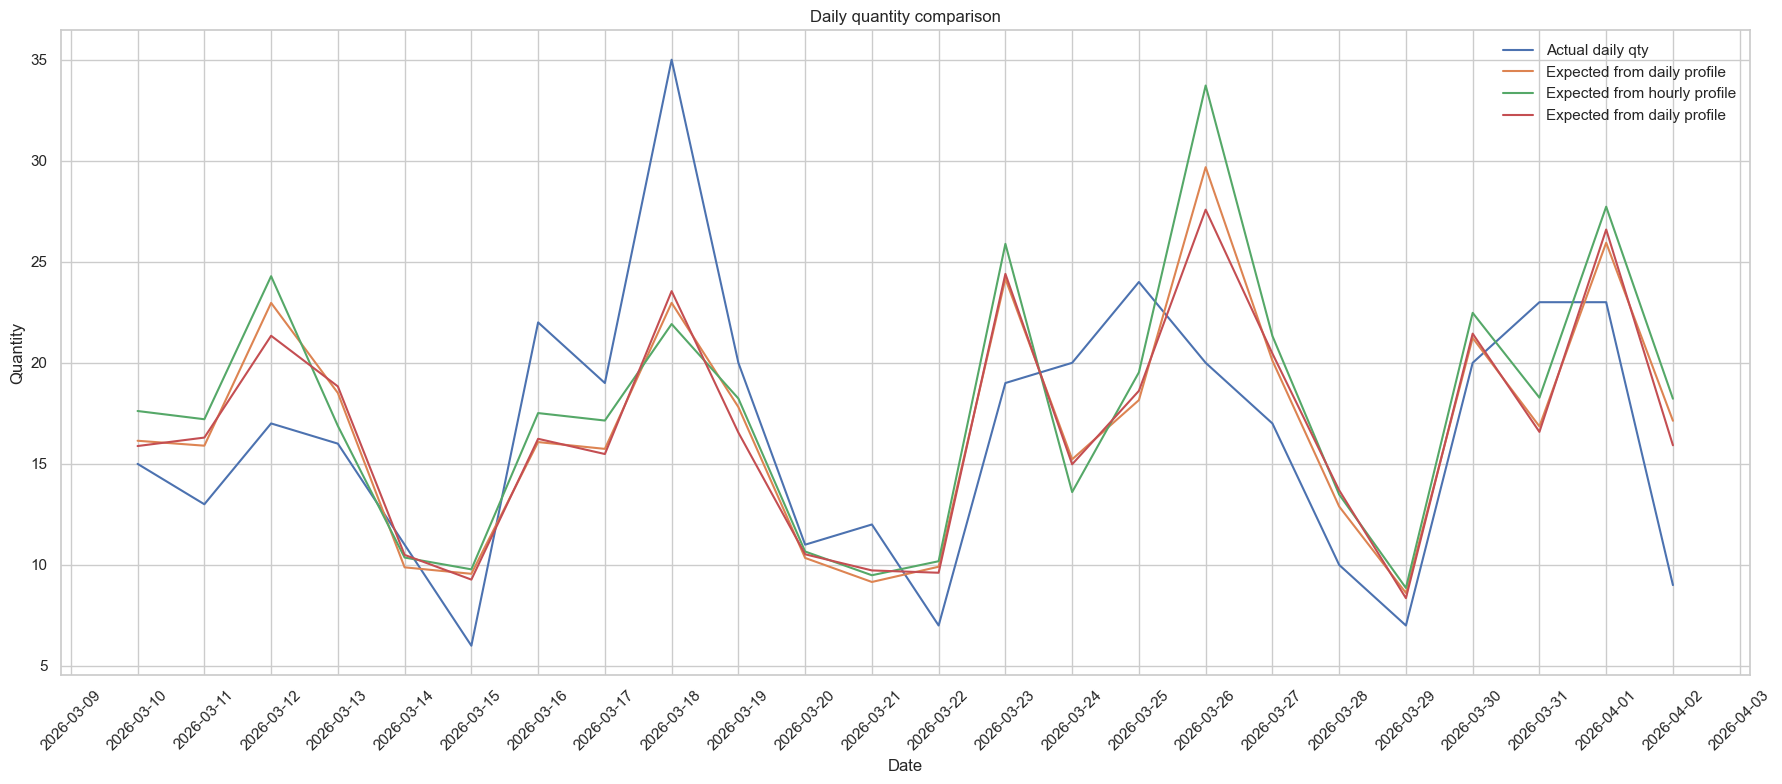

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(
    daily_last_30d['date'],
    daily_last_30d['actual_daily_qty'],
    label='Actual daily qty'
)

ax.plot(
    daily_last_30d['date'],
    daily_last_30d['expected_daily_qty_from_daily'],
    label='Expected from daily profile'
)

ax.plot(
    daily_last_30d['date'],
    daily_last_30d['expected_daily_qty_from_hourly'],
    label='Expected from hourly profile'
)

ax.plot(
    wdaily_last_30d['date'],
    wdaily_last_30d['expected_week_daily_qty_from_daily'],
    label='Expected from daily profile'
)


# ax.plot(
#     hdaily_last_30d['date'],
#     hdaily_last_30d['expected_7_20'],
#     label='Expected from hourly profile'
# )


# ax.plot(
#     qdaily_last_30d['date'],
#     qdaily_last_30d['expected_daily_qty_from_daily'],
#     label='Expected from daily profile'
# )

# ax.plot(
#     daily_last_30d['date'],
#     daily_last_30d['expected_daily_qty_from_hourly_zero_less'],
#     label='Expected from daily profile'
# )

ax.set(
    xlabel='Date',
    ylabel='Quantity',
    title='Daily quantity comparison'
)

# Дневная сетка
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax.grid(True, which='major', axis='both')

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig("test.png")

plt.show()

In [144]:
daily_last_30d

,date,bakery_daily_qty,actual_daily_qty,daily_share,average_daily_share,expected_daily_qty_from_daily,gap_daily,share_gap,expected_daily_qty_from_hourly,expected_daily_qty_from_hourly_zero_less,gap_hourly
212,2026-03-10,292.0,10.0,0.034247,0.035888,10.479299,0.479299,-0.001641,10.518281,31.295958,0.518281
213,2026-03-11,270.0,10.0,0.037037,0.035888,9.689763,-0.310237,0.001149,9.499760,28.134799,-0.500240
214,2026-03-12,337.0,16.0,0.047478,0.035888,12.094259,-3.905741,0.011590,12.368535,36.145055,-3.631465
215,2026-03-13,352.0,26.0,0.073864,0.035888,12.632579,-13.367421,0.037976,12.273566,38.067407,-13.726434
216,2026-03-14,365.0,12.0,0.032877,0.035888,13.099123,1.099123,-0.003011,12.634154,38.787424,0.634154
217,2026-03-15,274.0,10.0,0.036496,0.035888,9.833315,-0.166685,0.000608,8.830604,28.242764,-1.169396
218,2026-03-16,324.0,9.0,0.027778,0.035888,11.627715,2.627715,-0.008110,10.946971,34.189770,1.946971
219,2026-03-17,340.0,10.0,0.029412,0.035888,12.201923,2.201923,-0.006476,12.527064,37.593150,2.527064
220,2026-03-18,361.0,9.0,0.024931,0.035888,12.955571,3.955571,-0.010957,12.112586,37.275469,3.112586
221,2026-03-19,330.0,20.0,0.060606,0.035888,11.843043,-8.156957,0.024718,12.402735,35.093211,-7.597265


In [12]:
daily_last_30d['gap_daily'].mean()

np.float64(0.3727674138786341)

In [219]:
sum(hourly_df[hourly_df['date'] == '2026-11-03']['product_hour_qty'])

0

In [220]:
hourly_df[hourly_df['date'] == dt]

,date,hour,bakery_hour_qty,product_hour_qty,hour_share,avg_hour_share,n_obs,n_days,expected_hour_qty
147,2025-08-11,7,77.7,3.0,0.038610,0.035179,233.0,233.0,2.733371
148,2025-08-11,8,37.8,6.0,0.158730,0.023293,236.0,236.0,0.880483
149,2025-08-11,9,53.4,1.0,0.018727,0.032421,236.0,236.0,1.731257
150,2025-08-11,10,54.4,0.0,0.000000,0.015575,236.0,236.0,0.847302
151,2025-08-11,11,55.1,1.0,0.018149,0.016112,236.0,236.0,0.887785
152,2025-08-11,12,35.7,0.0,0.000000,0.015642,236.0,236.0,0.558417
153,2025-08-11,13,20.4,0.0,0.000000,0.011957,236.0,236.0,0.243918
154,2025-08-11,14,41.0,2.0,0.048780,0.012477,236.0,236.0,0.511544
155,2025-08-11,15,46.9,0.0,0.000000,0.012583,236.0,236.0,0.590136
156,2025-08-11,16,25.5,0.0,0.000000,0.007973,235.0,235.0,0.203302


In [221]:
df["date"] = df[DATE_COL].dt.normalize()
df["hour"] = df[DATETIME_COL].dt.hour
df[df['Дата продажи'] == dt]
df_hourly = df[(df['Дата продажи'] == dt) & (df['Касса.Торговая точка'] == TARGET_BAKERY)& (df['Категория'] == 'Выпечка сытная')].groupby(["date", "hour", "Номенклатура"], as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "product_hour_qty"})
df[(df['Дата продажи'] == dt) & (df['Номенклатура'] == "Pulpy Тропик")]
df_hour_sharely = df_hourly.copy()
df_hourly.groupby(["hour"], as_index=False)['product_hour_qty'].sum().rename(columns={'product_hour_qty': "hour_qty"})
df_hour_sharely = df_hour_sharely.merge(
    df_hourly.groupby(["hour"], as_index=False)['product_hour_qty'].sum().rename(columns={'product_hour_qty': "hour_qty"}),
    on="hour", 
    how="left")
df_hour_sharely['hour_share'] = df_hour_sharely['product_hour_qty'] / df_hour_sharely['hour_qty'].where(df_hour_sharely['hour_qty'] > 0)

C:\Users\dns\AppData\Local\Temp\ipykernel_18924\137254833.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = heatmap_pct.round(1).applymap(lambda v: f'{v:.1f}%' if pd.notna(v) else '')


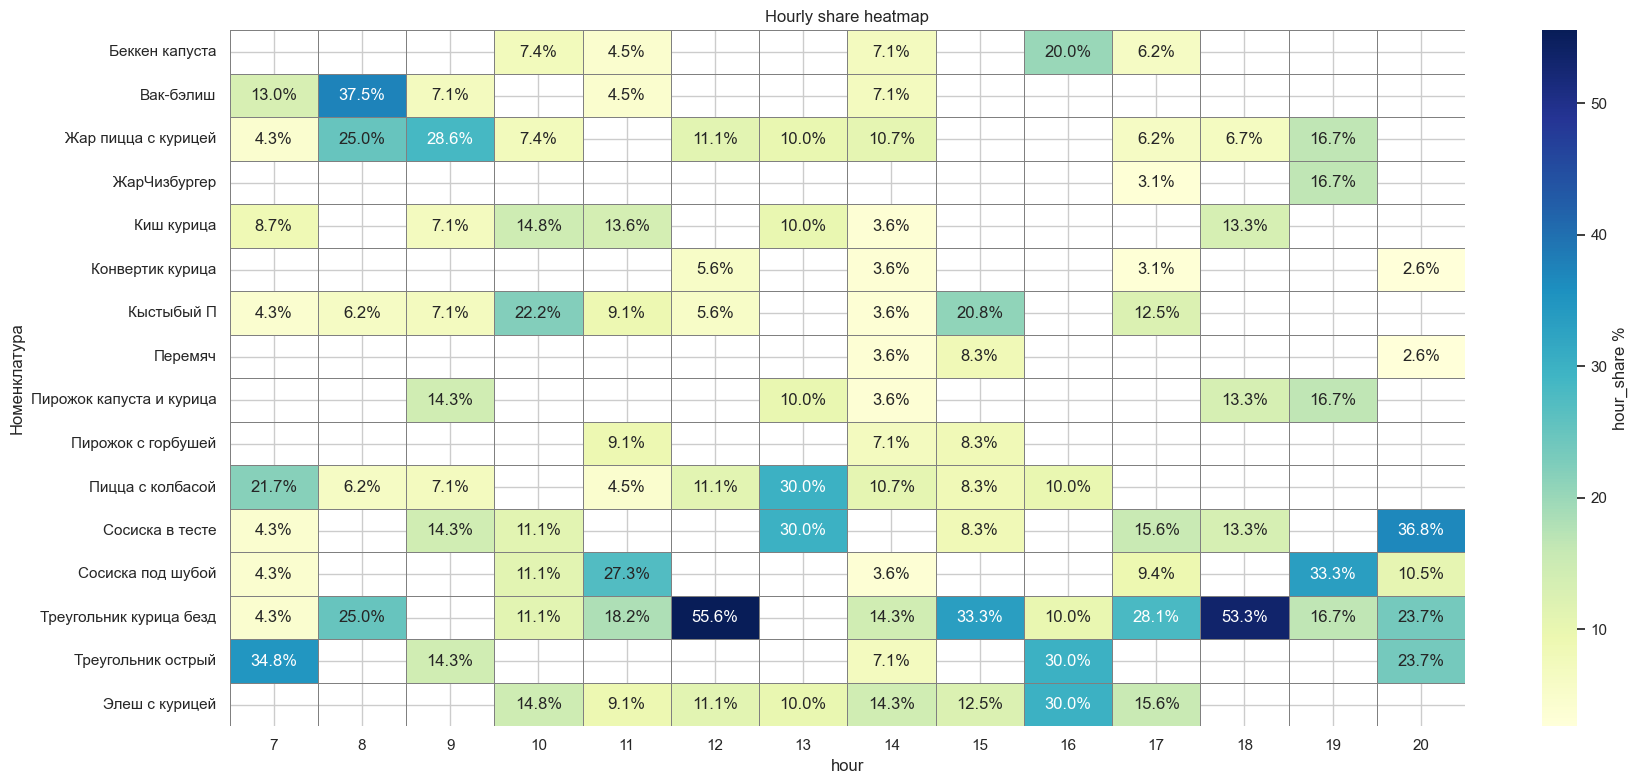

In [222]:
heatmap_data = df_hour_sharely.pivot(index=PRODUCT_COL, columns='hour', values='hour_share')
heatmap_data = heatmap_data.sort_index(axis=0).sort_index(axis=1)

heatmap_pct = heatmap_data * 100
annot = heatmap_pct.round(1).applymap(lambda v: f'{v:.1f}%' if pd.notna(v) else '')

plt.figure(figsize=(18, max(8, len(heatmap_data) * 0.25)))
sns.heatmap(
    heatmap_pct,
    annot=annot,
    fmt='',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'hour_share %'}
)
plt.xlabel('hour')
plt.ylabel('Номенклатура')
plt.title('Hourly share heatmap')
plt.tight_layout()

In [156]:
hourly_profiles = []

for nmk in df[(df['Касса.Торговая точка'] == TARGET_BAKERY) & (df['Категория'] == 'Выпечка сытная')]['Номенклатура'].unique():
    _,hourly_profile_df,_,_ = build_hourly_and_daily_profiles(df[(df['Касса.Торговая точка'] == TARGET_BAKERY) & (df['Категория'] == 'Выпечка сытная')], TARGET_BAKERY, nmk)
    hourly_profiles.append({nmk: hourly_profile_df})


In [223]:
len(df[(df['Касса.Торговая точка'] == TARGET_BAKERY) & (df['Категория'] == 'Выпечка сытная')]['Дата продажи'].unique())

236

In [224]:
df['Дата продажи'].min()

Timestamp('2025-08-01 00:00:00')

In [139]:

len(hourly_profiles)

24

In [147]:
df

,Дата продажи,Дата время чека,Вид события по кассе,Касса.Торговая точка,Категория,Номенклатура,Свежесть,Цена,Кол-во,date,hour
0,2026-01-01,2026-01-01 14:21:01,Продажа,Раскольникова 48/1 Наб Челны,Напитки горячие,Капучино 300,NaN,130.0,1.0,2026-01-01,14.0
1,2026-01-01,2026-01-01 14:21:01,Продажа,Раскольникова 48/1 Наб Челны,Пирожные,Красный Вельвет,Свежий,104.0,1.0,2026-01-01,14.0
2,2026-01-01,2026-01-01 14:34:10,Продажа,Раскольникова 48/1 Наб Челны,Прочие товары,Тесто дрожжевое,NaN,150.0,0.5,2026-01-01,14.0
3,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Пирожные,Красный Вельвет,Свежий,104.0,3.0,2026-01-01,14.0
4,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Кулинария сеть,Манты с говядиной и картофелем вес сеть,NaN,890.0,1.2,2026-01-01,14.0
...,...,...,...,...,...,...,...,...,...,...,...
29909054,NaT,NaT,Продажа,Энгельса 30 Зеленодольск,Кулинария сеть,Салат Цезарь вес сеть,NaN,849.0,0.2,NaT,NaN
29909055,NaT,NaT,Продажа,Энгельса 30 Зеленодольск,Прочие товары,Коррекс мал,Свежий,6.0,1.0,NaT,NaN
29909056,NaT,NaT,Продажа,Энгельса 30 Зеленодольск,Выпечка сытная,ЖарЧизбургер,Свежий,140.0,2.0,NaT,NaN
29909057,NaT,NaT,Продажа,Шамиля Усманова 47 Наб Челны,Напитки горячие,Капучино 300,Свежий,130.0,1.0,NaT,NaN


In [266]:
days_share = (
    df.groupby(PRODUCT_COL)[DATE_COL]
    .nunique()
    / df[DATE_COL].nunique()
)

valid_products = days_share[days_share >= 0.98].index

df_filtered = df[df[PRODUCT_COL].isin(valid_products)]

In [226]:
len(df_filtered['Номенклатура'].unique())

235

In [152]:
len(df['Номенклатура'].unique())

1041

In [287]:
hourly_profiles = {}

for nmk in df_filtered[(df_filtered['Касса.Торговая точка'] == TARGET_BAKERY) & (df_filtered['Категория'] == 'Выпечка сытная')]['Номенклатура'].unique():
    _,hourly_profile_df,_,_ = build_hourly_and_daily_profiles(df_filtered[(df_filtered['Касса.Торговая точка'] == TARGET_BAKERY) & (df_filtered['Категория'] == 'Выпечка сытная')], TARGET_BAKERY, nmk)
    hourly_profiles[nmk] = hourly_profile_df


In [234]:
hourly_profiles

{'Треугольник курица безд':     hour  avg_hour_share  n_obs  n_days
 0      0             NaN    NaN     NaN
 1      1             NaN    NaN     NaN
 2      2             NaN    NaN     NaN
 3      3             NaN    NaN     NaN
 4      4             NaN    NaN     NaN
 5      5             NaN    NaN     NaN
 6      6        0.116389   89.0    89.0
 7      7        0.162374  228.0   228.0
 8      8        0.181338  236.0   236.0
 9      9        0.178978  236.0   236.0
 10    10        0.190830  235.0   235.0
 11    11        0.157251  235.0   235.0
 12    12        0.149864  236.0   236.0
 13    13        0.164200  236.0   236.0
 14    14        0.140664  236.0   236.0
 15    15        0.159160  236.0   236.0
 16    16        0.173783  235.0   235.0
 17    17        0.188738  236.0   236.0
 18    18        0.186931  235.0   235.0
 19    19        0.154222  233.0   233.0
 20    20        0.144474  228.0   228.0
 21    21        0.251736   16.0    16.0
 22    22        0.000000    1

In [268]:
rows = []
for product_name, profile_df in hourly_profiles.items():
    row = profile_df.set_index("hour").reindex(range(24))["avg_hour_share"]
    row.name = product_name
    rows.append(row)
heatmap_data = pd.DataFrame(rows)
heatmap_data = heatmap_data.reindex(columns=range(24))
heatmap_data = heatmap_data.sort_index(axis=0).sort_index(axis=1)

In [237]:
print(type(hourly_profiles))
print(hourly_profiles if isinstance(hourly_profiles, dict) else len(hourly_profiles))

<class 'dict'>
{'Треугольник курица безд':     hour  avg_hour_share  n_obs  n_days
0      0             NaN    NaN     NaN
1      1             NaN    NaN     NaN
2      2             NaN    NaN     NaN
3      3             NaN    NaN     NaN
4      4             NaN    NaN     NaN
5      5             NaN    NaN     NaN
6      6        0.116389   89.0    89.0
7      7        0.162374  228.0   228.0
8      8        0.181338  236.0   236.0
9      9        0.178978  236.0   236.0
10    10        0.190830  235.0   235.0
11    11        0.157251  235.0   235.0
12    12        0.149864  236.0   236.0
13    13        0.164200  236.0   236.0
14    14        0.140664  236.0   236.0
15    15        0.159160  236.0   236.0
16    16        0.173783  235.0   235.0
17    17        0.188738  236.0   236.0
18    18        0.186931  235.0   235.0
19    19        0.154222  233.0   233.0
20    20        0.144474  228.0   228.0
21    21        0.251736   16.0    16.0
22    22        0.000000    1.0     1

C:\Users\dns\AppData\Local\Temp\ipykernel_18924\2332118896.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = heatmap_pct.round(1).applymap(lambda v: f'{v:.1f}%' if pd.notna(v) else '')


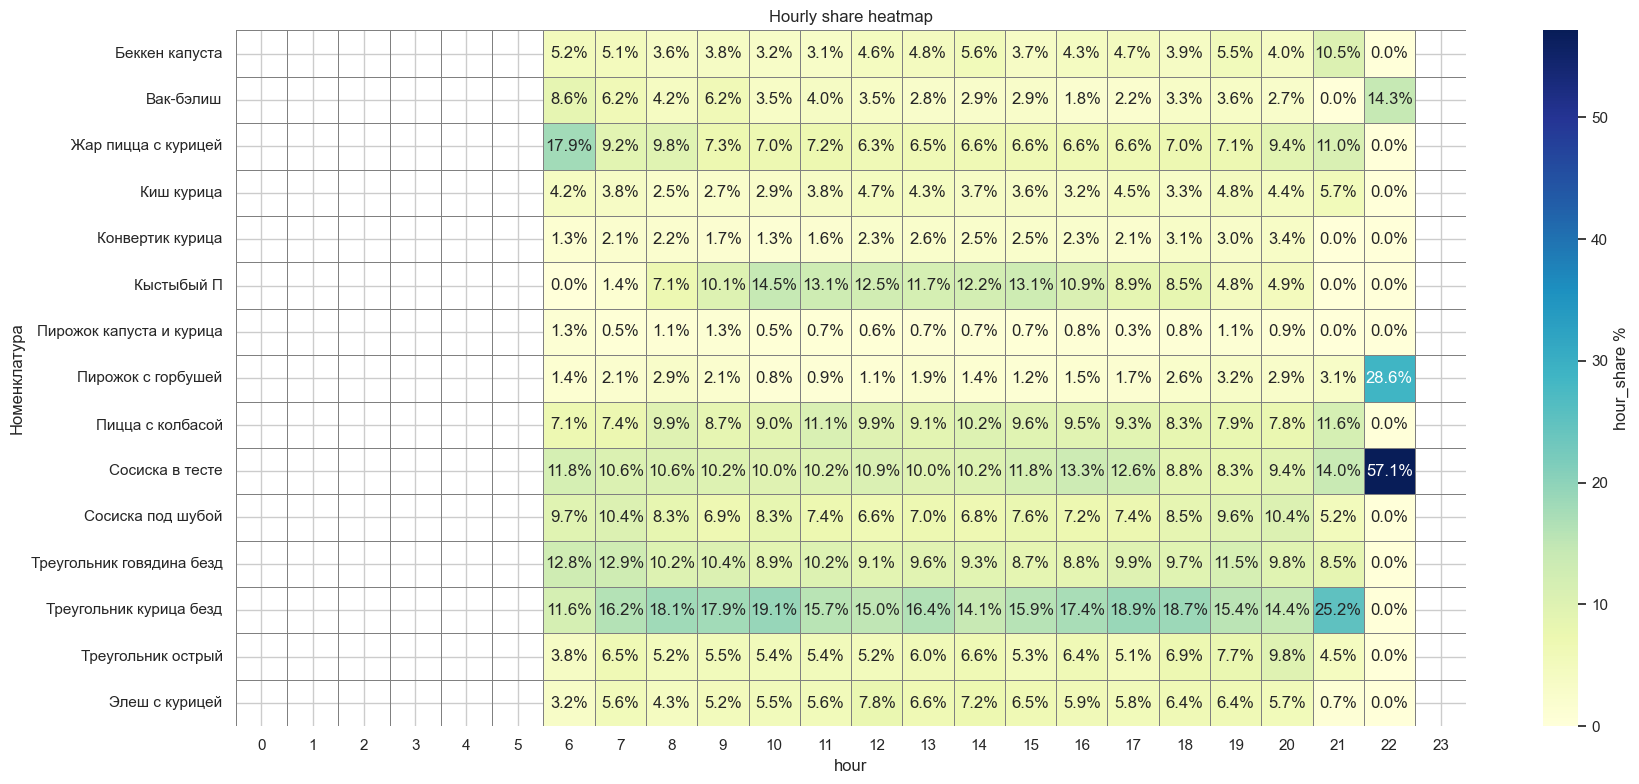

In [239]:


heatmap_pct = heatmap_data * 100
annot = heatmap_pct.round(1).applymap(lambda v: f'{v:.1f}%' if pd.notna(v) else '')

plt.figure(figsize=(18, max(8, len(heatmap_data) * 0.25)))
sns.heatmap(
    heatmap_pct,
    annot=annot,
    fmt='',
    cmap='YlGnBu',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'hour_share %'}
)
plt.xlabel('hour')
plt.ylabel('Номенклатура')
plt.title('Hourly share heatmap')
plt.tight_layout()

In [269]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')


def load_env_file(path: str | Path = '.env') -> dict[str, str]:
    env = {}
    path = Path(path)
    if not path.exists():
        return env
    for raw_line in path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        env[key.strip()] = value.strip()
    return env


env = load_env_file('.env')
host = env.get('HOST', os.getenv('HOST'))
port = env.get('PORT', os.getenv('PORT'))
username = env.get('USER', os.getenv('USER'))
password = env.get('PASSWORD', os.getenv('PASSWORD'))
database = env.get('DATABASE', os.getenv('DATABASE'))

client = clickhouse_connect.get_client(
    host=host,
    port=port,
    username=username,
    password=password,
    database=database,
)


In [270]:
df_sql = client.query_df("""
  SELECT DISTINCT
      fcl.*,
      dbs.bakery_name bakery_name,
      dbs.city city,
      dbs.price_region price_region,
      dps.product_name product_name,
      dps.category_name category_name
  FROM Svezhar.fct_check_lines AS fcl
  JOIN Svezhar.dim_bakeries AS dbs
      ON fcl.bakery_id = dbs.bakery_id
  JOIN Svezhar.dim_products AS dps
      ON fcl.product_id = dps.product_id
  WHERE dbs.bakery_name = 'Проспект Победы 147 Казань'
""")

df_sql.columns = [col.split('.')[-1] for col in df_sql.columns]

In [250]:
df_sql['check_date'].unique()

<DatetimeArray>
['2026-02-27 00:00:00', '2026-02-28 00:00:00', '2026-04-18 00:00:00',
 '2026-04-15 00:00:00', '2026-04-16 00:00:00', '2026-04-17 00:00:00',
 '2026-04-20 00:00:00', '2026-04-19 00:00:00', '2026-04-21 00:00:00',
 '2026-04-10 00:00:00', '2026-04-22 00:00:00', '2026-02-26 00:00:00',
 '2026-03-01 00:00:00', '2026-03-12 00:00:00', '2026-03-02 00:00:00',
 '2026-04-14 00:00:00', '2026-04-13 00:00:00', '2026-04-11 00:00:00']
Length: 18, dtype: datetime64[ns]

## SQL hourly heatmap for filtered bakery/category data

These cells build hourly profiles from the SQL dataframe, convert them into a heatmap matrix, and plot the result for newly loaded data.

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Беккен капуста,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.011715,0.024882,0.032575,...,0.049026,0.057878,0.050369,0.038011,0.073307,0.000000,0.016667,0.000000,NaN,NaN
Вак-бэлиш,NaN,NaN,NaN,NaN,NaN,NaN,0.1875,0.049930,0.044703,0.097942,...,0.011622,0.055602,0.033393,0.068465,0.021452,0.048623,0.000000,0.083333,NaN,NaN
Жар пицца с курицей,NaN,NaN,NaN,NaN,NaN,NaN,0.0875,0.079521,0.101361,0.102503,...,0.064839,0.019732,0.047648,0.031362,0.034124,0.040952,0.068254,0.000000,NaN,NaN
Киш грибы курица,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.016702,0.010865,0.002564,...,0.054692,0.021784,0.004396,0.021972,0.011934,0.009804,0.071181,0.000000,NaN,NaN
Киш курица,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.029770,0.002551,0.004603,...,0.023580,0.044816,0.023191,0.029613,0.033503,0.026308,0.040046,0.000000,NaN,NaN


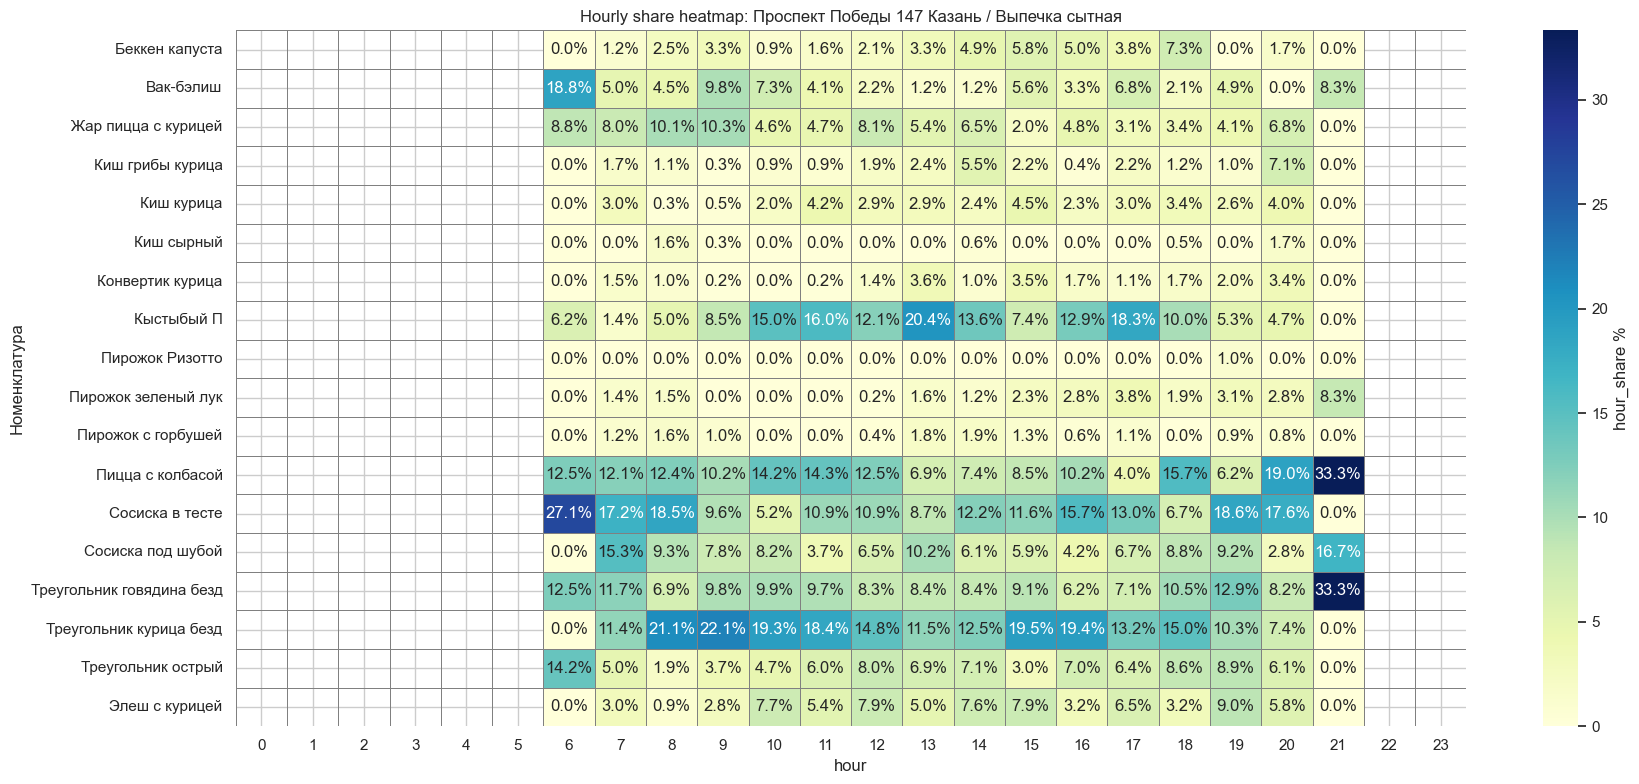

Saved to: C:\Users\dns\Desktop\Projects\demand-forecasting-model\reports\monthly_demand_review\Проспект Победы 147 Казань_Выпечка сытная_hourly_heatmap.png
Columns: {'bakery_col': 'bakery_name', 'category_col': 'category_name', 'product_col': 'product_name', 'date_col': 'check_date', 'datetime_col': 'check_datetime', 'qty_col': 'quantity'}


In [271]:
def infer_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    raise KeyError(f'None of the columns were found: {candidates}')


def build_hourly_and_daily_profiles_generic(
    month_df,
    bakery,
    product,
    date_col,
    datetime_col,
    bakery_col,
    product_col,
    qty_col,
):
    bakery_df = month_df[month_df[bakery_col] == bakery].copy()
    if bakery_df.empty:
        raise ValueError(f'Bakery not found in selected data: {bakery}')

    bakery_df['date'] = bakery_df[date_col].dt.normalize()
    bakery_df['hour'] = bakery_df[datetime_col].dt.hour

    product_df = bakery_df[bakery_df[product_col] == product].copy()
    if product_df.empty:
        raise ValueError(f'Product not found for bakery {bakery}: {product}')

    bakery_hourly = bakery_df.groupby(['date', 'hour'], as_index=False)[qty_col].sum().rename(columns={qty_col: 'bakery_hour_qty'})
    product_hourly = product_df.groupby(['date', 'hour'], as_index=False)[qty_col].sum().rename(columns={qty_col: 'product_hour_qty'})
    hourly = bakery_hourly.merge(product_hourly, on=['date', 'hour'], how='left')
    hourly['product_hour_qty'] = hourly['product_hour_qty'].fillna(0.0)
    hourly['hour_share'] = hourly['product_hour_qty'] / hourly['bakery_hour_qty'].where(hourly['bakery_hour_qty'] > 0)

    hourly_profile = (
        hourly.dropna(subset=['hour_share'])
        .groupby('hour', as_index=False)
        .agg(
            avg_hour_share=('hour_share', 'mean'),
            n_obs=('hour_share', 'count'),
            n_days=('date', 'nunique'),
        )
    )
    hourly_profile = pd.DataFrame({'hour': list(range(24))}).merge(hourly_profile, on='hour', how='left')

    hourly = hourly.merge(hourly_profile[['hour', 'avg_hour_share']], on='hour', how='left')
    hourly['expected_hour_qty'] = hourly['bakery_hour_qty'] * hourly['avg_hour_share']

    daily_from_hourly = (
        hourly.groupby('date', as_index=False)[['bakery_hour_qty', 'product_hour_qty', 'expected_hour_qty']]
        .sum()
        .rename(columns={
            'bakery_hour_qty': 'bakery_daily_qty',
            'product_hour_qty': 'actual_daily_qty_from_hourly',
            'expected_hour_qty': 'expected_daily_qty_from_hourly',
        })
    )

    bakery_daily = bakery_df.groupby('date', as_index=False)[qty_col].sum().rename(columns={qty_col: 'bakery_daily_qty'})
    product_daily = product_df.groupby('date', as_index=False)[qty_col].sum().rename(columns={qty_col: 'actual_daily_qty'})
    daily = bakery_daily.merge(product_daily, on='date', how='left')
    daily['actual_daily_qty'] = daily['actual_daily_qty'].fillna(0.0)
    daily['daily_share'] = daily['actual_daily_qty'] / daily['bakery_daily_qty'].where(daily['bakery_daily_qty'] > 0)

    average_daily_share = daily['daily_share'].dropna().mean()
    if pd.isna(average_daily_share):
        average_daily_share = 0.0

    daily['expected_daily_qty_from_daily'] = daily['bakery_daily_qty'] * average_daily_share
    daily['gap_daily'] = daily['expected_daily_qty_from_daily'] - daily['actual_daily_qty']
    daily['share_gap'] = daily['daily_share'] - average_daily_share
    daily = daily.merge(daily_from_hourly[['date', 'expected_daily_qty_from_hourly']], on='date', how='left')
    daily['gap_hourly'] = daily['expected_daily_qty_from_hourly'] - daily['actual_daily_qty']

    return hourly, hourly_profile, daily, average_daily_share


def build_hourly_profiles_from_filtered_df(df_filtered, bakery, category):
    bakery_col = infer_column(df_filtered, ['bakery_name', 'Касса.Торговая точка'])
    category_col = infer_column(df_filtered, ['category_name', 'Категория'])
    product_col = infer_column(df_filtered, ['product_name', 'Номенклатура'])
    date_col = infer_column(df_filtered, ['check_date', 'Дата продажи', 'date'])
    datetime_col = infer_column(df_filtered, ['check_datetime', 'check_time', 'Дата время чека', 'datetime'])
    qty_col = infer_column(df_filtered, ['qty', 'quantity', 'check_qty', 'Кол-во'])

    prepared = df_filtered.copy()
    prepared[date_col] = pd.to_datetime(prepared[date_col], errors='coerce', dayfirst=True)
    prepared[datetime_col] = pd.to_datetime(prepared[datetime_col], errors='coerce', dayfirst=True)
    prepared[qty_col] = pd.to_numeric(prepared[qty_col], errors='coerce')
    prepared = prepared.dropna(subset=[date_col, datetime_col])

    prepared = prepared[(prepared[bakery_col] == bakery) & (prepared[category_col] == category)].copy()
    if prepared.empty:
        raise ValueError(f'No rows found for bakery={bakery!r}, category={category!r}')

    hourly_profiles = {}
    for product in prepared[product_col].dropna().unique():
        _, hourly_profile_df, _, _ = build_hourly_and_daily_profiles_generic(
            prepared,
            bakery,
            product,
            date_col,
            datetime_col,
            bakery_col,
            product_col,
            qty_col,
        )
        hourly_profiles[product] = hourly_profile_df

    return hourly_profiles, {
        'bakery_col': bakery_col,
        'category_col': category_col,
        'product_col': product_col,
        'date_col': date_col,
        'datetime_col': datetime_col,
        'qty_col': qty_col,
    }


def build_hourly_heatmap_data(hourly_profiles):
    rows = []
    for product_name, profile_df in hourly_profiles.items():
        row = profile_df.set_index('hour').reindex(range(24))['avg_hour_share']
        row.name = product_name
        rows.append(row)

    heatmap_data = pd.DataFrame(rows)
    heatmap_data = heatmap_data.reindex(columns=range(24))
    heatmap_data = heatmap_data.sort_index(axis=0).sort_index(axis=1)
    return heatmap_data


def plot_hourly_profiles_heatmap(heatmap_data, title, out_path=None):
    heatmap_pct = heatmap_data * 100
    annot = heatmap_pct.round(1).apply(lambda col: col.map(lambda v: f'{v:.1f}%' if pd.notna(v) else ''))

    plt.figure(figsize=(18, max(8, len(heatmap_data) * 0.25)))
    sns.heatmap(
        heatmap_pct,
        annot=annot,
        fmt='',
        cmap='YlGnBu',
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'hour_share %'},
    )
    plt.xlabel('hour')
    plt.ylabel('Номенклатура')
    plt.title(title)
    plt.tight_layout()

    if out_path is not None:
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=160, bbox_inches='tight')

    plt.show()
    return out_path


TARGET_BAKERY_SQL = 'Проспект Победы 147 Казань'
TARGET_CATEGORY_SQL = 'Выпечка сытная'

hourly_profiles_sql, sql_cols = build_hourly_profiles_from_filtered_df(
    df_sql,
    TARGET_BAKERY_SQL,
    TARGET_CATEGORY_SQL,
)

heatmap_data_sql = build_hourly_heatmap_data(hourly_profiles_sql)
display(heatmap_data_sql.head())

sql_heatmap_path = plot_hourly_profiles_heatmap(
    heatmap_data_sql,
    title=f'Hourly share heatmap: {TARGET_BAKERY_SQL} / {TARGET_CATEGORY_SQL}',
    out_path=REPORT_DIR / f'{TARGET_BAKERY_SQL.replace("/", "_").replace("\\", "_")}_{TARGET_CATEGORY_SQL.replace("/", "_").replace("\\", "_")}_hourly_heatmap.png',
)

print('Saved to:', sql_heatmap_path)
print('Columns:', sql_cols)


In [274]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter
def plot_daily_vs_hourly_profile(
      df_filtered: pd.DataFrame,
      hourly_profiles: dict[str, pd.DataFrame],
      bakery: str,
      product: str,
      out_path: Path | None = None,
  ):
      bakery_col = infer_column(df_filtered, ["bakery_name", "Касса.Торговая точка"])
      product_col = infer_column(df_filtered, ["product_name", "Номенклатура"])
      date_col = infer_column(df_filtered, ["check_date", "Дата продажи", "date"])
      datetime_col = infer_column(df_filtered, ["check_datetime", "check_time", "datetime", "Дата время чека"])
      qty_col = infer_column(df_filtered, ["qty", "quantity", "check_qty", "Кол-во"])

      data = df_filtered.copy()
      data[date_col] = pd.to_datetime(data[date_col], errors="coerce", dayfirst=True)
      data[datetime_col] = pd.to_datetime(data[datetime_col], errors="coerce", dayfirst=True)
      data[qty_col] = pd.to_numeric(data[qty_col], errors="coerce")
      data = data.dropna(subset=[date_col, datetime_col, qty_col])

      bakery_df = data[data[bakery_col] == bakery].copy()
      if bakery_df.empty:
          raise ValueError(f"Bakery not found in data: {bakery}")

      product_df = bakery_df[bakery_df[product_col] == product].copy()
      if product_df.empty:
          raise ValueError(f"Product not found for bakery {bakery}: {product}")

      if product not in hourly_profiles:
          raise KeyError(f"Product not found in hourly_profiles: {product}")

      profile_df = hourly_profiles[product][["hour", "avg_hour_share"]].copy()

      bakery_df["date"] = bakery_df[date_col].dt.normalize()
      bakery_df["hour"] = bakery_df[datetime_col].dt.hour

      product_df["date"] = product_df[date_col].dt.normalize()
      product_df["hour"] = product_df[datetime_col].dt.hour

      bakery_hourly = (
          bakery_df.groupby(["date", "hour"], as_index=False)[qty_col]
          .sum()
          .rename(columns={qty_col: "bakery_hour_qty"})
      )

      product_hourly = (
          product_df.groupby(["date", "hour"], as_index=False)[qty_col]
          .sum()
          .rename(columns={qty_col: "actual_product_hour_qty"})
      )

      hourly = bakery_hourly.merge(product_hourly, on=["date", "hour"], how="left")
      hourly["actual_product_hour_qty"] = hourly["actual_product_hour_qty"].fillna(0.0)
      hourly = hourly.merge(profile_df, on="hour", how="left")
      hourly["expected_product_hour_qty"] = hourly["bakery_hour_qty"] * hourly["avg_hour_share"]

      daily = (
          hourly.groupby("date", as_index=False)
          .agg(
              bakery_daily_qty=("bakery_hour_qty", "sum"),
              actual_daily_qty=("actual_product_hour_qty", "sum"),
              expected_daily_qty=("expected_product_hour_qty", "sum"),
          )
      )

      daily["daily_share"] = daily["actual_daily_qty"] / daily["bakery_daily_qty"].where(daily["bakery_daily_qty"] > 0)
      daily["expected_share"] = daily["expected_daily_qty"] / daily["bakery_daily_qty"].where(daily["bakery_daily_qty"]
  > 0)

      fig, axes = plt.subplots(2, 1, figsize=(18, 12), gridspec_kw={"height_ratios": [2, 1]})
      daily_plot = daily.copy()
      daily_plot["date"] = pd.to_datetime(daily_plot["date"])

      axes[0].plot(daily_plot["date"], daily_plot["actual_daily_qty"], label="Actual", linewidth=2, color="black")
      axes[0].plot(daily_plot["date"], daily_plot["expected_daily_qty"], label="Expected from hourly profile",
  linewidth=2, color="#1f77b4")
      axes[0].set_title(f"{bakery} / {product} - actual vs expected daily sales")
      axes[0].legend()
      axes[0].grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
      axes[0].grid(True, which="major", axis="y", alpha=0.3)
      axes[0].xaxis.set_major_locator(DayLocator(interval=1))
      axes[0].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
      axes[0].tick_params(axis="x", rotation=45)

      axes[1].plot(daily_plot["date"], daily_plot["daily_share"], marker="o", linewidth=1.5, color="#d95f02",
  label="Actual share")
      axes[1].plot(daily_plot["date"], daily_plot["expected_share"], marker="o", linewidth=1.5, color="#2ca02c",
  label="Expected share")
      axes[1].set_title("Daily share in bakery sales")
      axes[1].set_ylabel("Share")
      axes[1].legend()
      axes[1].grid(True, axis="y", alpha=0.3)
      axes[1].xaxis.set_major_locator(DayLocator(interval=1))
      axes[1].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
      axes[1].tick_params(axis="x", rotation=45)

      plt.tight_layout()

      if out_path is not None:
          out_path.parent.mkdir(parents=True, exist_ok=True)
          fig.savefig(out_path, dpi=160, bbox_inches="tight")

      plt.show()
      return daily, hourly, out_path

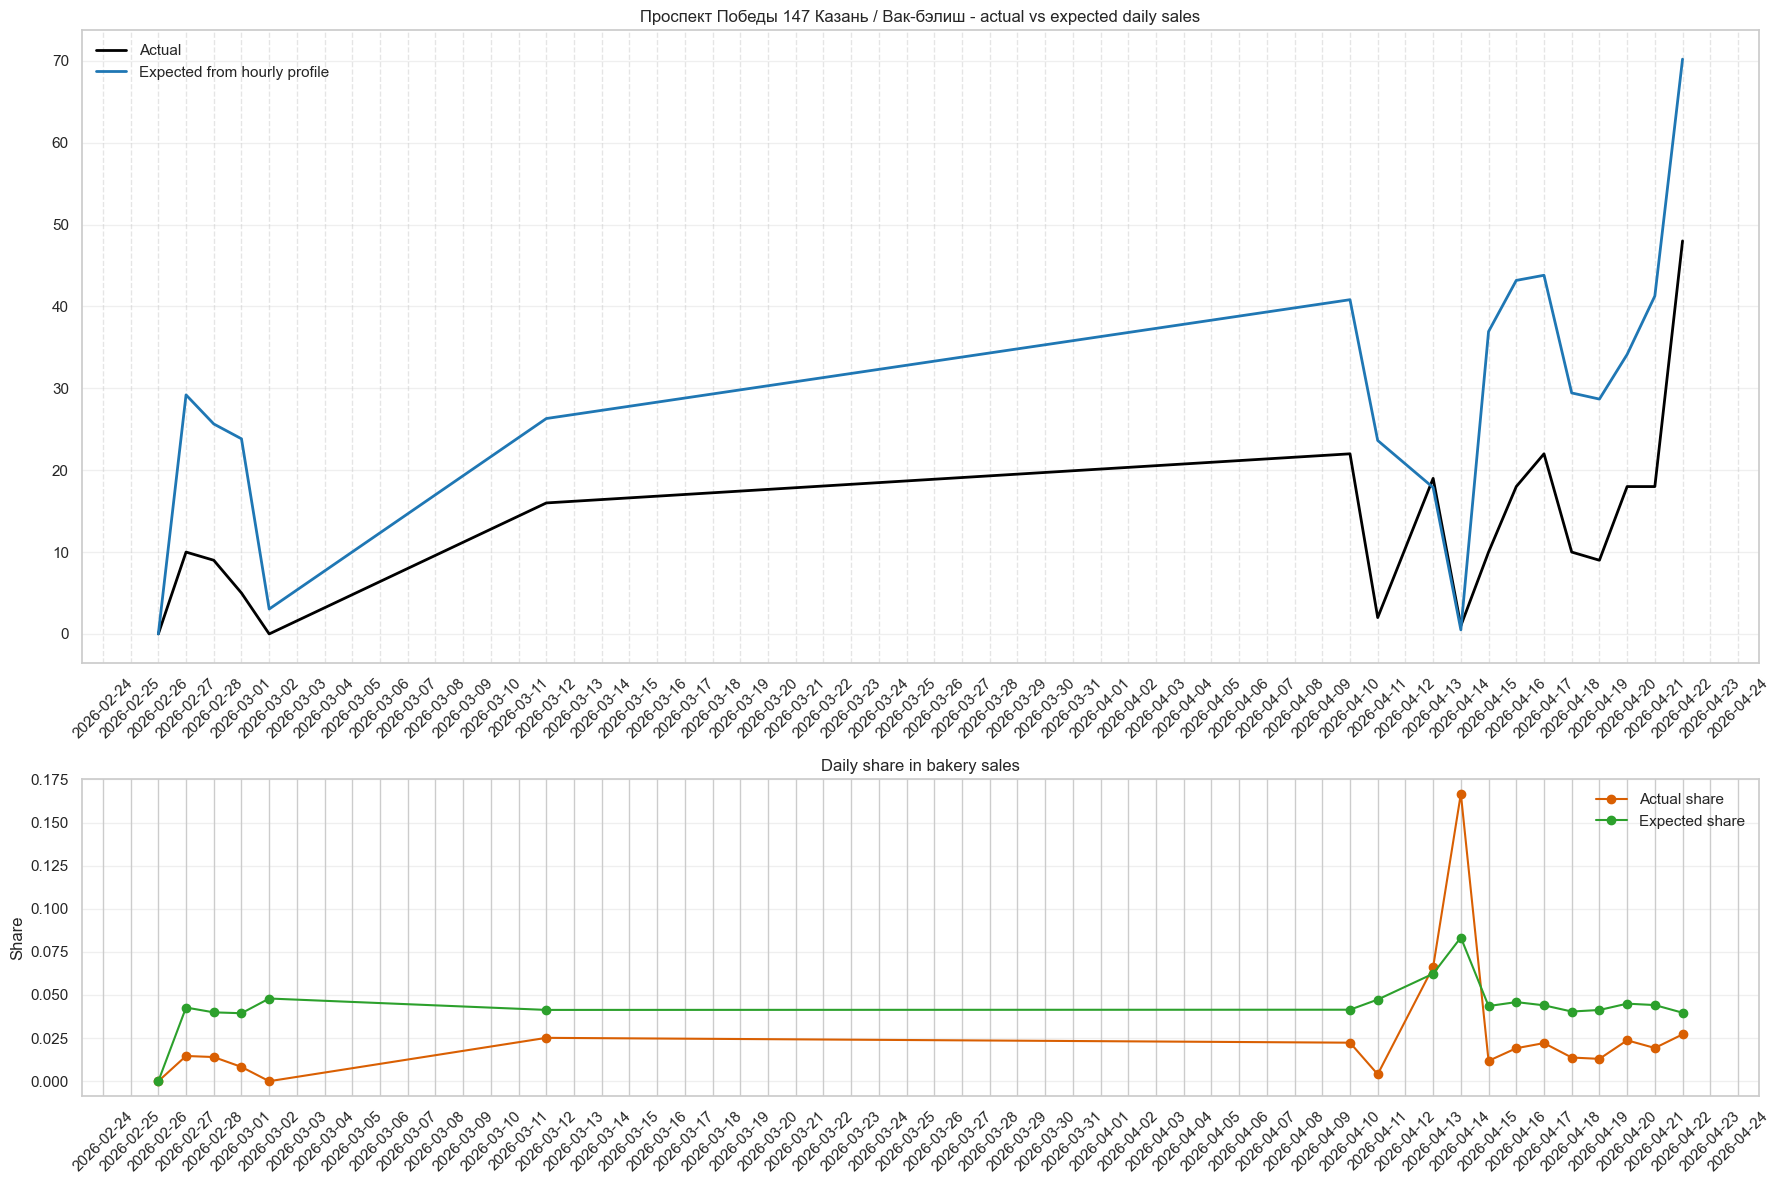

In [276]:
daily, hourly, plot_path = plot_daily_vs_hourly_profile(
      df_filtered=df_sql,
      hourly_profiles=hourly_profiles_sql,
      bakery="Проспект Победы 147 Казань",
      product="Вак-бэлиш",
      out_path=REPORT_DIR / "vbak_belish_daily_vs_hourly.png",
  )

In [288]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter


def plot_daily_vs_existing_hourly_profile(
    month_df: pd.DataFrame,
    hourly_profiles: dict[str, pd.DataFrame],
    bakery: str,
    product: str,
    date_col: str,
    datetime_col: str,
    bakery_col: str,
    product_col: str,
    qty_col: str,
    month_tag: str,
    out_dir: Path | None = None,
):
    """
    Compare actual daily sales for one SKU against the expected daily sales
    reconstructed from an already-built hourly profile.

    The function expects hourly_profiles[product] to contain:
        - hour
        - avg_hour_share
    """
    if out_dir is None:
        out_dir = Path("reports") / "monthly_demand_review"

    if product not in hourly_profiles:
        raise KeyError(f"Product not found in hourly_profiles: {product}")

    data = month_df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors="coerce", dayfirst=True)
    data[datetime_col] = pd.to_datetime(data[datetime_col], errors="coerce", dayfirst=True)
    data[qty_col] = pd.to_numeric(data[qty_col], errors="coerce")
    data = data.dropna(subset=[date_col, datetime_col, qty_col])

    bakery_df = data[data[bakery_col] == bakery].copy()
    if bakery_df.empty:
        raise ValueError(f"Bakery not found in data: {bakery}")

    product_df = bakery_df[bakery_df[product_col] == product].copy()
    if product_df.empty:
        raise ValueError(f"Product not found for bakery {bakery}: {product}")

    profile_df = hourly_profiles[product][["hour", "avg_hour_share"]].copy()

    bakery_df["date"] = bakery_df[date_col].dt.normalize()
    bakery_df["hour"] = bakery_df[datetime_col].dt.hour

    product_df["date"] = product_df[date_col].dt.normalize()
    product_df["hour"] = product_df[datetime_col].dt.hour

    bakery_hourly = (
        bakery_df.groupby(["date", "hour"], as_index=False)[qty_col]
        .sum()
        .rename(columns={qty_col: "bakery_hour_qty"})
    )

    product_hourly = (
        product_df.groupby(["date", "hour"], as_index=False)[qty_col]
        .sum()
        .rename(columns={qty_col: "actual_product_hour_qty"})
    )

    hourly = bakery_hourly.merge(product_hourly, on=["date", "hour"], how="left")
    hourly["actual_product_hour_qty"] = hourly["actual_product_hour_qty"].fillna(0.0)
    hourly = hourly.merge(profile_df, on="hour", how="left")
    hourly["expected_product_hour_qty"] = hourly["bakery_hour_qty"] * hourly["avg_hour_share"]

    daily = (
        hourly.groupby("date", as_index=False)
        .agg(
            bakery_daily_qty=("bakery_hour_qty", "sum"),
            actual_daily_qty=("actual_product_hour_qty", "sum"),
            expected_daily_qty=("expected_product_hour_qty", "sum"),
        )
    )

    daily["daily_share"] = daily["actual_daily_qty"] / daily["bakery_daily_qty"].where(daily["bakery_daily_qty"] > 0)
    daily["expected_share"] = daily["expected_daily_qty"] / daily["bakery_daily_qty"].where(daily["bakery_daily_qty"] > 0)
    daily["gap_qty"] = daily["expected_daily_qty"] - daily["actual_daily_qty"]

    daily_plot = daily.copy()
    daily_plot["date"] = pd.to_datetime(daily_plot["date"])

    fig, axes = plt.subplots(2, 1, figsize=(18, 12), gridspec_kw={"height_ratios": [2, 1]})

    axes[0].plot(daily_plot["date"], daily_plot["actual_daily_qty"], label="Actual", linewidth=2, color="black")
    axes[0].plot(
        daily_plot["date"],
        daily_plot["expected_daily_qty"],
        label="Expected from existing hourly profile",
        linewidth=2,
        color="#1f77b4",
    )
    axes[0].set_title(f"{bakery} / {product} - actual vs expected daily sales")
    axes[0].legend()
    axes[0].grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
    axes[0].grid(True, which="major", axis="y", alpha=0.3)
    axes[0].xaxis.set_major_locator(DayLocator(interval=1))
    axes[0].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].plot(
        daily_plot["date"],
        daily_plot["daily_share"],
        marker="o",
        linewidth=1.5,
        color="#d95f02",
        label="Actual share",
    )
    axes[1].plot(
        daily_plot["date"],
        daily_plot["expected_share"],
        marker="o",
        linewidth=1.5,
        color="#2ca02c",
        label="Expected share",
    )
    axes[1].set_title("Daily share in bakery sales")
    axes[1].set_ylabel("Share")
    axes[1].legend()
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].xaxis.set_major_locator(DayLocator(interval=1))
    axes[1].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()

    out_dir.mkdir(parents=True, exist_ok=True)
    safe_bakery = bakery.replace("/", "_").replace("\\", "_")
    safe_product = product.replace("/", "_").replace("\\", "_")
    out_path = out_dir / f"{month_tag}_{safe_bakery}_{safe_product}_daily_vs_existing_hourly_profile.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()

    return daily, hourly, out_path


# Example usage:
# daily, hourly, plot_path = plot_daily_vs_existing_hourly_profile(
#     month_df=month_df,
#     hourly_profiles=hourly_profiles,
#     bakery="Проспект Победы 147 Казань",
#     product="Вак-бэлиш",
#     date_col=DATE_COL,
#     datetime_col=DATETIME_COL,
#     bakery_col=BAKERY_COL,
#     product_col=PRODUCT_COL,
#     qty_col=QTY_COL,
#     month_tag=month_tag,
# )
# print("Saved to:", plot_path)


In [280]:
target_month = pd.Period("2026-02", freq="M")
month_df = df[df[DATE_COL].dt.to_period("M") == target_month].copy()

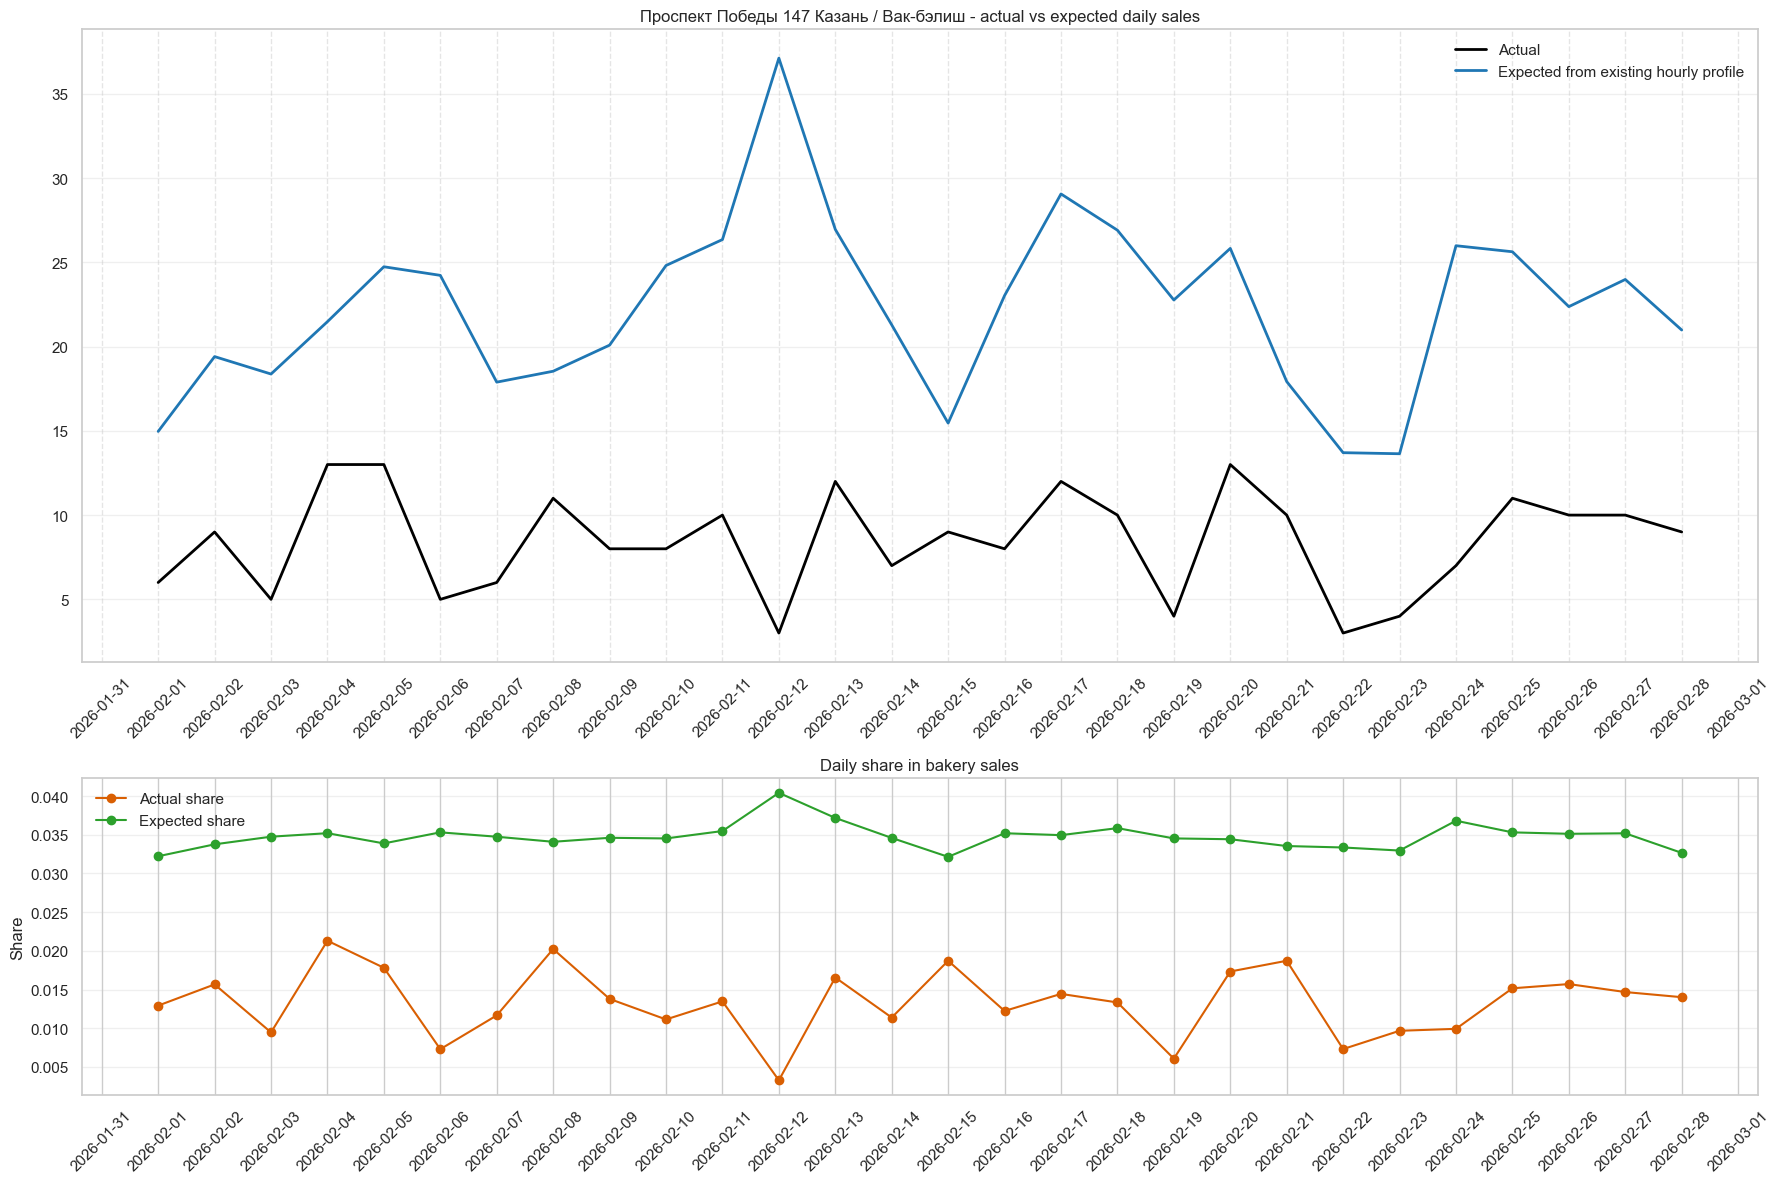

Saved to: reports\monthly_demand_review\2026_03_Проспект Победы 147 Казань_Вак-бэлиш_daily_vs_existing_hourly_profile.png


In [289]:
daily, hourly, plot_path = plot_daily_vs_existing_hourly_profile(
    month_df=month_df,
    hourly_profiles=hourly_profiles,
    bakery="Проспект Победы 147 Казань",
    product="Вак-бэлиш",
    date_col=DATE_COL,
    datetime_col=DATETIME_COL,
    bakery_col=BAKERY_COL,
    product_col=PRODUCT_COL,
    qty_col=QTY_COL,
    month_tag=month_tag,
)
print("Saved to:", plot_path)

In [6]:
df_147 = df[(df['Касса.Торговая точка'] == 'Проспект Победы 147 Казань') & (df['Номенклатура'] == 'Вак-бэлиш')]

In [7]:
df_147["hour"] = df_147[DATETIME_COL].dt.hour

C:\Users\dns\AppData\Local\Temp\ipykernel_2440\595840263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_147["hour"] = df_147[DATETIME_COL].dt.hour


In [47]:
dff = df_147[df_147["hour"] == 19].groupby(df['Дата продажи'])['Кол-во'].sum()

In [49]:
len(dff)

56

In [46]:
print(df_147[df_147["hour"] == 19].to_string())

         Дата продажи     Дата время чека Вид события по кассе        Касса.Торговая точка       Категория Номенклатура Свежесть  Цена  Кол-во  hour
132662     2026-01-03 2026-01-03 19:42:41              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
2224465    2026-01-22 2026-01-22 19:06:15              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     5.0    19
5094628    2026-02-15 2026-02-15 19:33:10              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
6693185    2026-02-28 2026-02-28 19:30:51              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
6907161    2026-03-10 2026-03-10 19:05:51              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
7321937    2026-03-13 2026-03-13 19:30:34              Продажа  Проспект Победы 147 Казань  Выпечка сытная

In [51]:
print(f'для последней продажи c 19 по 20 доля от всех продаж {len(df_147[df_147["hour"] == 19].groupby(df['Дата продажи']))/len(df_147.groupby(df['Дата продажи']))}')
print(f'для последней продажи c 19 по 20 всего таких дней {len(df_147[df_147["hour"] == 19].groupby(df['Дата продажи']))}')
print('\n')
print(f'для последней продажи с 20 по 21 доля от всех продаж {len(df_147[df_147["hour"] == 20].groupby(df['Дата продажи']))/len(df_147.groupby(df['Дата продажи']))}')
print(f'для последней продажи с 20 по 21 всего таких дней {len(df_147[df_147["hour"] == 20].groupby(df['Дата продажи']))}')
print(f'всего дней {len(df_147.groupby(df['Дата продажи']))}')

для последней продажи c 19 по 20 доля от всех продаж 0.2413793103448276
для последней продажи c 19 по 20 всего таких дней 56


для последней продажи с 20 по 21 доля от всех продаж 0.16810344827586207
для последней продажи с 20 по 21 всего таких дней 39
всего дней 232


In [63]:
import numpy as np

In [64]:
np.sort(df_147["hour"].unique())

array([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22],
      dtype=int32)

In [61]:
d

In [67]:
for h in np.sort(df_147["hour"].unique()):
    print(f'час = {h} количество дней с продажами в этот час = {len(df_147[df_147["hour"] == h].groupby(df['Дата продажи']))}')

час = 6 количество дней с продажами в этот час = 10
час = 7 количество дней с продажами в этот час = 119
час = 8 количество дней с продажами в этот час = 113
час = 9 количество дней с продажами в этот час = 116
час = 10 количество дней с продажами в этот час = 71
час = 11 количество дней с продажами в этот час = 92
час = 12 количество дней с продажами в этот час = 103
час = 13 количество дней с продажами в этот час = 72
час = 14 количество дней с продажами в этот час = 68
час = 15 количество дней с продажами в этот час = 65
час = 16 количество дней с продажами в этот час = 54
час = 17 количество дней с продажами в этот час = 59
час = 18 количество дней с продажами в этот час = 59
час = 19 количество дней с продажами в этот час = 56
час = 20 количество дней с продажами в этот час = 39
час = 22 количество дней с продажами в этот час = 1


In [ ]:
df_147_pivot = (
    df_147
    .groupby([DATE_COL, "hour"], as_index=True)[QTY_COL]
    .sum()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

df_147_pivot